# 08 — ABCD Landing: background source and mother composition

This notebook extends the Mother Tracking studies (`02`, `05`, `06`) to the full ABCD landing sample.

- Event-level landing yield is measured from the isolation planes.
- Mother yield/composition is measured from the role-specific mother-PDG histograms.
- Each topology has eight regions: `SR-A`–`SR-D` and `VR-A`–`VR-D`.
- ABCD encoding follows the producer: `A=0 (pass, pass)`, `B=1 (fail, pass)`, `C=2 (pass, fail)`, `D=3 (fail, fail)`.

> Event yields and mother-object yields are intentionally kept separate; the latter can contain more than one entry per event.

In [1]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Compatibility for files written with NumPy 2.x and read in the current image.
if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
%matplotlib inline

In [2]:
cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")

INPUT_DIR = study_dir / "ABCD_landing_bkg_full_merge"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50",
    "WW", "WZ", "ZZ",
]

# Fixed plotting order, bottom to top for stacked bars.
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [sample for sample in SAMPLES if sample.startswith("DYJets")],
    "QCD": [sample for sample in SAMPLES if sample.startswith("QCD_")],
}
SAMPLE_TO_GROUP = {
    sample: group
    for group, samples in BACKGROUND_GROUPS.items()
    for sample in samples
}

ABCD_REGIONS = {"A": 0, "B": 1, "C": 2, "D": 3}
TOPOLOGY_CONFIG = {
    "2mu2e": {
        "channels": {"SR": "test_SR_2mu2e", "VR": "test_VR_2mu2e"},
        "plane_hist": "mulj_egmlj_iso",
        "cuts": (0.25, 0.10),
        "roles": {
            "mu-LJ": "2mu2e_mulj",
            "egm-LJ": "2mu2e_egmlj",
        },
    },
    "4mu": {
        "channels": {"SR": "test_SR_4mu", "VR": "test_VR_4mu"},
        "plane_hist": "mulj_mulj_iso",
        "cuts": (0.25, 0.25),
        "roles": {
            "leading mu-LJ": "4mu_mulj0",
            "subleading mu-LJ": "4mu_mulj1",
        },
    },
}

GROUP_COLORS = {
    "QCD": "#6F2DA8",
    "DY": "#E69F00",
    "TT": "#0072B2",
    "Diboson": "#009E73",
}
MOTHER_COLORS = {
    "Z": "#0072B2", "W": "#E69F00", "e": "#CC79A7",
    r"$\pi$": "#009E73", r"$\eta$/$\omega$": "#56B4E9",
    "B Meson": "#D55E00", "D Meson": "#F0E442",
    "Quark/Gluon": "#6F2DA8", r"J/$\Psi$": "#8C564B",
    "Others": "#7F7F7F",
}
SAMPLE_COLORS = {
    sample: plt.get_cmap("turbo")(index / max(len(SAMPLES) - 1, 1))
    for index, sample in enumerate(SAMPLES)
}

assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing_files = [sample for sample in SAMPLES if not (INPUT_DIR / f"{sample}.coffea").is_file()]
assert not missing_files, f"Missing coffea files: {missing_files}"
print(f"Input: {INPUT_DIR}")
print(f"Samples: {len(SAMPLES)}")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/ABCD_landing_bkg_full_merge
Samples: 18


## Load and validate merged outputs

In [3]:
out = {}
validation_rows = []

required_hists = {config["plane_hist"] for config in TOPOLOGY_CONFIG.values()}
for config in TOPOLOGY_CONFIG.values():
    for role_suffix in config["roles"].values():
        required_hists.add(f"fs_gen_mother_id_{role_suffix}_abcd")

for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    available_hists = set(sample_out["hists"])
    missing_hists = sorted(required_hists - available_hists)
    metadata = sample_out.get("metadata", {})
    validation_rows.append({
        "sample": sample,
        "group": SAMPLE_TO_GROUP[sample],
        "n_events_processed": metadata.get("n_evts", np.nan),
        "scaled_sum_weights": metadata.get("scaled_sum_weights", np.nan),
        "missing_histograms": ", ".join(missing_hists),
        "status": "ok" if not missing_hists else "missing histogram",
    })

validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all(), "At least one sample is missing a required histogram"

,group,n_events_processed,scaled_sum_weights,missing_histograms,status
sample,,,,,
TTJets,TT,2396626,8.725062e+06,,ok
QCD_Pt15To20,QCD,853,6.266705e+06,,ok
QCD_Pt20To30,QCD,22954,5.241206e+07,,ok
QCD_Pt30To50,QCD,107897,6.114577e+07,,ok
QCD_Pt50To80,QCD,212290,4.209357e+07,,ok
QCD_Pt80To120,QCD,641772,4.492515e+07,,ok
QCD_Pt120To170,QCD,605553,1.799175e+07,,ok
QCD_Pt170To300,QCD,3795715,5.737628e+07,,ok
QCD_Pt300To470,QCD,6999747,5.643064e+07,,ok


## ABCD plane overview

Start with the isolation planes that define A/B/C/D. Each bin shows the event yield summed over all background samples. These are not background-process counts or mother-object counts. The red dashed lines are the isolation thresholds used to divide the four ABCD regions.

For consistency with the downstream yield integration, all underflow and overflow bins are included. They are folded into the nearest visible edge bin before plotting, including the four 2D corner flow bins.

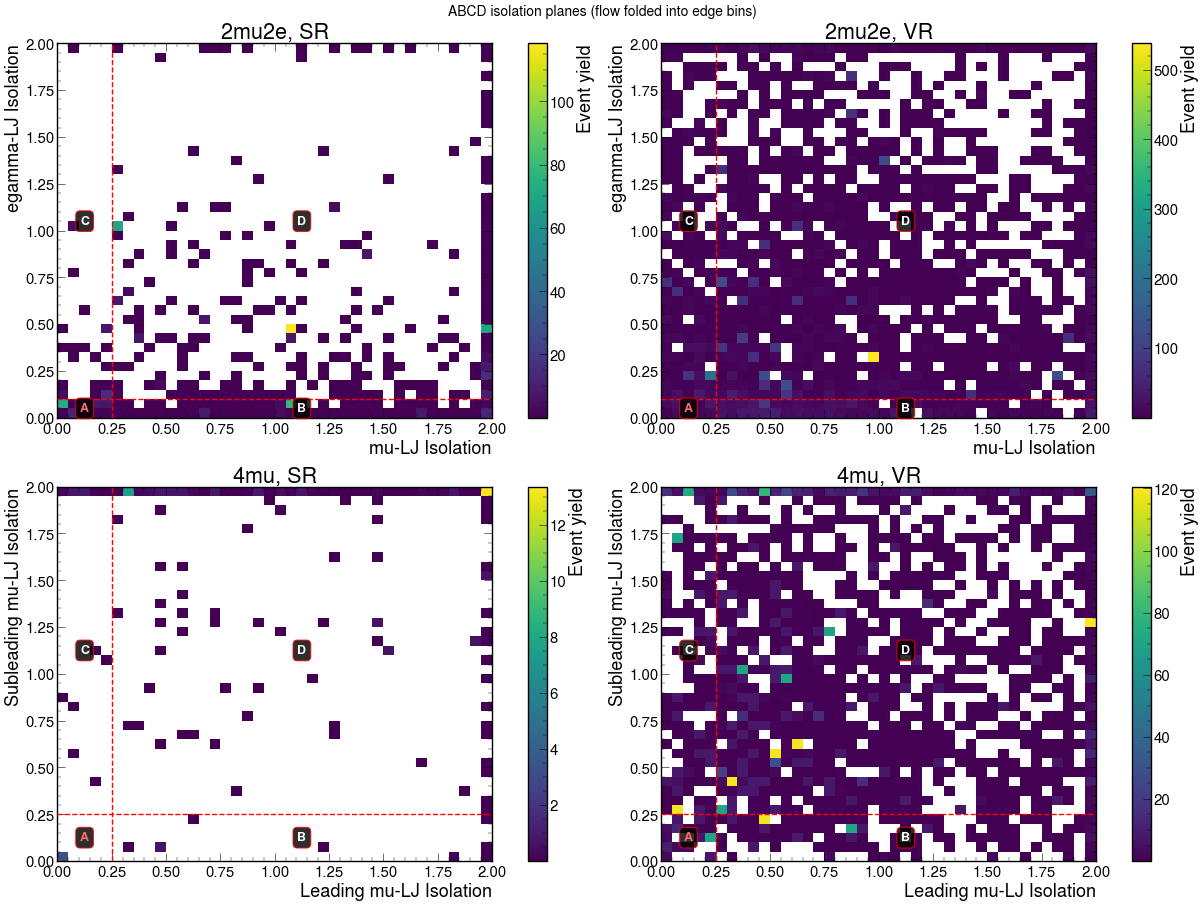

In [4]:
def combined_plane(topology):
    config = TOPOLOGY_CONFIG[topology]
    total = None
    for sample in SAMPLES:
        histogram = out[sample]["hists"][config["plane_hist"]]
        total = histogram.copy() if total is None else total + histogram
    return total


def folded_2d_values(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    folded = values[1:-1, 1:-1].copy()
    folded[0, :] += values[0, 1:-1]
    folded[-1, :] += values[-1, 1:-1]
    folded[:, 0] += values[1:-1, 0]
    folded[:, -1] += values[1:-1, -1]
    folded[0, 0] += values[0, 0]
    folded[0, -1] += values[0, -1]
    folded[-1, 0] += values[-1, 0]
    folded[-1, -1] += values[-1, -1]
    return folded


fig, axes = plt.subplots(2, 2, figsize=(24, 18), constrained_layout=True)
for ax, (topology, selection) in zip(axes.flat, [
    ("2mu2e", "SR"), ("2mu2e", "VR"), ("4mu", "SR"), ("4mu", "VR")
]):
    config = TOPOLOGY_CONFIG[topology]
    plane = combined_plane(topology)[{"channel": config["channels"][selection]}]
    values = np.abs(folded_2d_values(plane)).T
    positive = np.ma.masked_less_equal(values, 0)
    xedges = np.asarray(plane.axes[0].edges)
    yedges = np.asarray(plane.axes[1].edges)
    mesh = ax.pcolormesh(xedges, yedges, positive, shading="auto")
    xcut, ycut = config["cuts"]
    boundary_color = "red"
    ax.axvline(xcut, color=boundary_color, linestyle="--", linewidth=2, zorder=3)
    ax.axhline(ycut, color=boundary_color, linestyle="--", linewidth=2, zorder=3)

    positions = {
        "A": ((xedges[0] + xcut) / 2, (yedges[0] + ycut) / 2),
        "B": ((xcut + xedges[-1]) / 2, (yedges[0] + ycut) / 2),
        "C": ((xedges[0] + xcut) / 2, (ycut + yedges[-1]) / 2),
        "D": ((xcut + xedges[-1]) / 2, (ycut + yedges[-1]) / 2),
    }
    label_box = dict(
        boxstyle="round,pad=0.35",
        facecolor="black",
        edgecolor=boundary_color,
        linewidth=1.5,
        alpha=0.82,
    )
    for region, (xpos, ypos) in positions.items():
        ax.text(
            xpos, ypos, region,
            ha="center", va="center", fontsize=18, fontweight="bold",
            color="#FF6B6B" if region == "A" else "white",
            bbox=label_box, zorder=4,
        )

    ax.set(
        xlabel=plane.axes[0].label,
        ylabel=plane.axes[1].label,
        title=f"{topology}, {selection}",
    )
    fig.colorbar(mesh, ax=ax, label="Event yield")
fig.suptitle("ABCD isolation planes (flow folded into edge bins)", fontsize=20)
plt.show()
plt.close(fig)

## Helpers

The isolation-plane yield is integrated using bin centers and the same strict pass convention used by the ABCD producer (`iso < cut`). Underflow and overflow are retained. Mother histograms are sliced directly with their stored `abcd_region` axis.

Flow policy: isolation-plane integrations include all flow bins; 2D displays fold them into visible edge bins; mother-PDG flow entries are assigned to `Others`.

In [5]:
MOTHER_CATEGORY_ORDER = [
    "Z", "W", "e", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$\Psi$", "Others",
]

def categorize_background_mother(pdgid):
    abs_id = abs(int(pdgid))
    if abs_id == 23:
        return "Z"
    if abs_id == 24:
        return "W"
    if abs_id == 11:
        return "e"
    if abs_id in (111, 211):
        return r"$\pi$"
    if abs_id in (221, 223):
        return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541):
        return "B Meson"
    if abs_id in (411, 421, 423, 431):
        return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21):
        return "Quark/Gluon"
    if abs_id == 443:
        return r"J/$\Psi$"
    return "Others"

def values_and_variances(histogram, flow=False):
    values = np.asarray(histogram.values(flow=flow), dtype=float)
    variances = histogram.variances(flow=flow)
    if variances is None:
        variances = np.abs(values)
    else:
        variances = np.asarray(variances, dtype=float)
        variances = np.where(np.isfinite(variances) & (variances >= 0), variances, 0.0)
    return values, variances

def _axis_centers_with_flow(axis):
    centers = np.asarray(axis.centers, dtype=float)
    return np.concatenate(([-np.inf], centers, [np.inf]))

def plane_region_yield(sample, topology, selection, region):
    config = TOPOLOGY_CONFIG[topology]
    channel = config["channels"][selection]
    histogram = out[sample]["hists"][config["plane_hist"]][{"channel": channel}]
    values, variances = values_and_variances(histogram, flow=True)
    xcenters = _axis_centers_with_flow(histogram.axes[0])
    ycenters = _axis_centers_with_flow(histogram.axes[1])
    xpass = xcenters < config["cuts"][0]
    ypass = ycenters < config["cuts"][1]
    masks = {
        "A": xpass[:, None] & ypass[None, :],
        "B": ~xpass[:, None] & ypass[None, :],
        "C": xpass[:, None] & ~ypass[None, :],
        "D": ~xpass[:, None] & ~ypass[None, :],
    }
    mask = masks[region]
    return float(values[mask].sum()), float(variances[mask].sum())

def mother_histogram(sample, topology, role, selection, region):
    config = TOPOLOGY_CONFIG[topology]
    channel = config["channels"][selection]
    role_suffix = config["roles"][role]
    histogram_name = f"fs_gen_mother_id_{role_suffix}_abcd"
    return out[sample]["hists"][histogram_name][{
        "channel": channel,
        "abcd_region": hist.loc(ABCD_REGIONS[region]),
    }]

def categorize_mother_histogram(histogram):
    values, variances = values_and_variances(histogram, flow=True)
    centers = np.asarray(histogram.axes[0].centers, dtype=int)
    yields = defaultdict(float)
    category_variances = defaultdict(float)
    for pdgid, value, variance in zip(centers, values[1:-1], variances[1:-1]):
        category = categorize_background_mother(pdgid)
        yields[category] += float(value)
        category_variances[category] += float(variance)
    # Exact PDG categories outside the stored axis range are unavailable.
    yields["Others"] += float(values[0] + values[-1])
    category_variances["Others"] += float(variances[0] + variances[-1])
    return yields, category_variances

def region_labels(topology):
    return [f"{selection}-{region}" for selection in ("SR", "VR") for region in ABCD_REGIONS]

def safe_fractions(table):
    totals = table.sum(axis=1)
    return table.div(totals.replace(0, np.nan), axis=0).fillna(0.0)

def plot_stacked_table(table, title, ylabel, logy=False, colors=None, figsize=(24, 12)):
    ax = table.plot(
        kind="bar", stacked=True, figsize=figsize,
        color=colors, edgecolor="black", linewidth=0.4,
    )
    if logy:
        ax.set_yscale("log")
    ax.set(title=title, xlabel="Region", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_fraction_heatmap(table, title, figsize=(24, 12)):
    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(table.T.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(table.index)), labels=table.index, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.columns)), labels=table.columns)
    ax.set(title=title, xlabel="Region", ylabel="Mother category")
    fig.colorbar(image, ax=ax, label="Fraction of mother-object yield")
    plt.tight_layout()
    plt.show()
    plt.close()

## Event yield tables by ABCD region

These tables contain event yield only; they do not use mother information. They are retained as numerical references, while the region-by-region visualization is shown only as background-process fractions in the next section.

In [6]:
sample_landing_yields = {}
group_landing_yields = {}
group_landing_errors = {}

for topology in TOPOLOGY_CONFIG:
    sample_rows = []
    for selection in ("SR", "VR"):
        for region in ABCD_REGIONS:
            label = f"{selection}-{region}"
            row = {"region": label}
            for sample in SAMPLES:
                value, variance = plane_region_yield(sample, topology, selection, region)
                row[sample] = value
            sample_rows.append(row)
    sample_table = pd.DataFrame(sample_rows).set_index("region")
    sample_landing_yields[topology] = sample_table

    grouped = pd.DataFrame(index=sample_table.index)
    grouped_errors = pd.DataFrame(index=sample_table.index)
    for group, samples in BACKGROUND_GROUPS.items():
        grouped[group] = sample_table[samples].sum(axis=1)
        variances = []
        for selection in ("SR", "VR"):
            for region in ABCD_REGIONS:
                variances.append(sum(
                    plane_region_yield(sample, topology, selection, region)[1]
                    for sample in samples
                ))
        grouped_errors[group] = np.sqrt(variances)
    group_landing_yields[topology] = grouped
    group_landing_errors[topology] = grouped_errors

    display(Markdown(f"### {topology}: grouped background landing yield"))
    display(grouped.round(4))
    display(Markdown(f"### {topology}: individual sample landing yield"))
    display(sample_table.round(4))


### 2mu2e: grouped background landing yield

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0000,0.0000,6.4961,95.0589
SR-B,0.0000,6.5473,0.0000,122.4629
SR-C,0.0000,6.5473,0.0000,24.4118
SR-D,0.0000,13.0946,0.0000,353.2586
VR-A,2.8038,108.0306,9.7441,8.8749
VR-B,0.4134,756.2143,19.2624,101.6423
VR-C,2.0174,193.1456,83.3199,714.3678
VR-D,0.0000,566.3423,6.4961,3749.4079


### 2mu2e: individual sample landing yield

,TTJets,QCD_Pt15To20,QCD_Pt20To30,QCD_Pt30To50,QCD_Pt50To80,QCD_Pt80To120,QCD_Pt120To170,QCD_Pt170To300,QCD_Pt300To470,QCD_Pt470To600,QCD_Pt600To800,QCD_Pt800To1000,QCD_Pt1000,DYJetsToLL_M10to50,DYJetsToLL_M50,WW,WZ,ZZ
region,,,,,,,,,,,,,,,,,,
SR-A,0.0000,0.0,0.0,0.0,0.0000,0.0000,70.4988,21.9825,1.9762,0.3743,0.1750,0.0386,0.0135,0.0000,6.4961,0.0000,0.0000,0.0000
SR-B,6.5473,0.0,0.0,0.0,0.0000,0.0000,70.4988,29.3100,15.1507,4.1171,2.5090,0.5528,0.3245,0.0000,0.0000,0.0000,0.0000,0.0000
SR-C,6.5473,0.0,0.0,0.0,0.0000,0.0000,0.0000,21.9825,1.9762,0.2807,0.1459,0.0231,0.0034,0.0000,0.0000,0.0000,0.0000,0.0000
SR-D,13.0946,0.0,0.0,0.0,0.0000,118.3545,140.9975,65.9476,22.3967,3.1814,1.6921,0.4859,0.2028,0.0000,0.0000,0.0000,0.0000,0.0000
VR-A,108.0306,0.0,0.0,0.0,0.0000,0.0000,0.0000,7.3275,1.3175,0.1871,0.0292,0.0103,0.0034,0.0000,9.7441,0.4028,0.8268,1.5742
VR-B,756.2143,0.0,0.0,0.0,0.0000,0.0000,70.4988,21.9825,6.5873,1.5907,0.7585,0.1568,0.0676,9.5183,9.7441,0.0000,0.4134,0.0000
VR-C,193.1456,0.0,0.0,0.0,0.0000,118.3545,281.9951,271.1179,38.2062,3.3685,1.1086,0.1697,0.0473,47.5914,35.7284,0.0000,1.0336,0.9839
VR-D,566.3423,0.0,0.0,0.0,537.6994,591.7723,1198.4790,1025.8517,324.7524,48.3801,17.3005,3.7459,1.4266,0.0000,6.4961,0.0000,0.0000,0.0000


### 4mu: grouped background landing yield

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0000,0.0000,3.2480,0.0026
SR-B,0.0000,0.0000,0.0000,0.7521
SR-C,0.0000,0.0000,0.0000,1.8063
SR-D,0.0000,3.2737,0.0000,28.8380
VR-A,0.4134,16.3683,29.0065,94.7912
VR-B,0.0000,9.8210,0.0000,261.8397
VR-C,0.2067,19.6419,3.2480,406.9455
VR-D,0.4134,39.2839,6.4961,1926.8307


### 4mu: individual sample landing yield

,TTJets,QCD_Pt15To20,QCD_Pt20To30,QCD_Pt30To50,QCD_Pt50To80,QCD_Pt80To120,QCD_Pt120To170,QCD_Pt170To300,QCD_Pt300To470,QCD_Pt470To600,QCD_Pt600To800,QCD_Pt800To1000,QCD_Pt1000,DYJetsToLL_M10to50,DYJetsToLL_M50,WW,WZ,ZZ
region,,,,,,,,,,,,,,,,,,
SR-A,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0026,0.0000,0.0000,3.2480,0.0,0.0000,0.0
SR-B,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.6587,0.0000,0.0583,0.0283,0.0068,0.0000,0.0000,0.0,0.0000,0.0
SR-C,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,1.3175,0.1871,0.2334,0.0514,0.0169,0.0000,0.0000,0.0,0.0000,0.0
SR-D,3.2737,0.0,0.0,0.0,0.0,0.0000,0.0000,14.6550,7.9047,3.0878,1.8380,0.8690,0.4834,0.0000,0.0000,0.0,0.0000,0.0
VR-A,16.3683,0.0,0.0,0.0,0.0,0.0000,70.4988,21.9825,1.9762,0.2807,0.0292,0.0103,0.0135,9.5183,19.4882,0.0,0.4134,0.0
VR-B,9.8210,0.0,0.0,0.0,0.0,118.3545,70.4988,51.2926,15.8094,3.5557,1.6338,0.4448,0.2502,0.0000,0.0000,0.0,0.0000,0.0
VR-C,19.6419,0.0,0.0,0.0,0.0,118.3545,140.9975,124.5677,15.1507,5.0528,2.0130,0.4576,0.3516,0.0000,3.2480,0.0,0.2067,0.0
VR-D,39.2839,0.0,0.0,0.0,0.0,473.4179,352.4938,784.0438,224.6259,52.9609,26.0529,8.3506,4.8850,0.0000,6.4961,0.0,0.4134,0.0


## Background-process composition by ABCD region

This is the QCD/DY/TT/Diboson fraction of the event yield in each region. It is not generator-mother composition. Region-by-region composition is visualized only as fractions; the main yield visualization is the Inclusive/Signal-like/Bkg-like comparison below.

### 2mu2e: background-source fractions

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0%,0.0%,6.4%,93.6%
SR-B,0.0%,5.08%,0.0%,94.92%
SR-C,0.0%,21.15%,0.0%,78.85%
SR-D,0.0%,3.57%,0.0%,96.43%
VR-A,2.17%,83.45%,7.53%,6.86%
VR-B,0.05%,86.18%,2.2%,11.58%
VR-C,0.2%,19.45%,8.39%,71.95%
VR-D,0.0%,13.1%,0.15%,86.75%


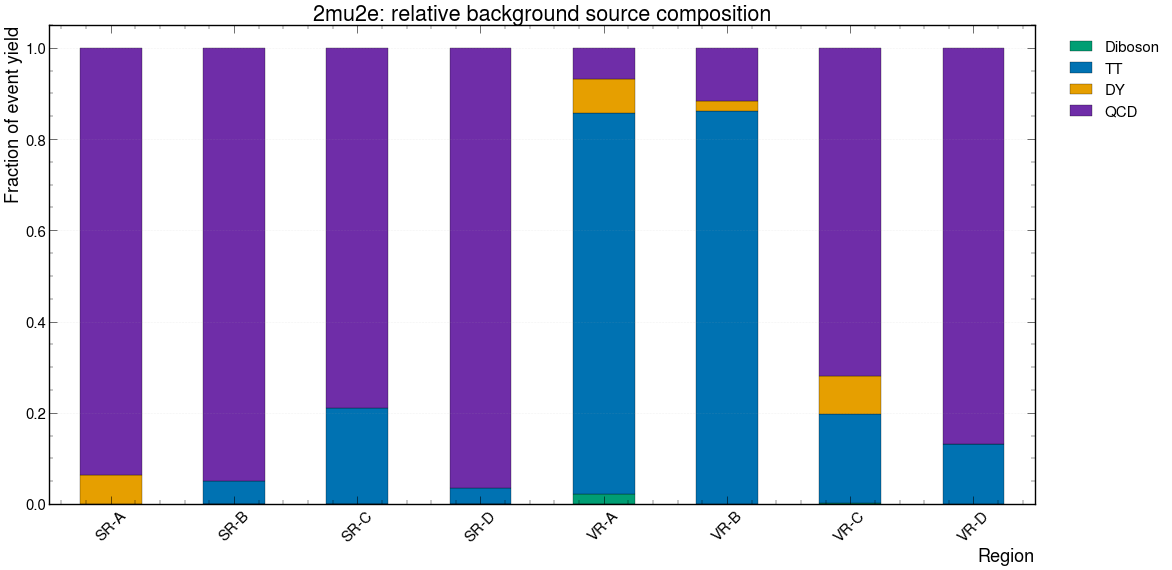

### 4mu: background-source fractions

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0%,0.0%,99.92%,0.08%
SR-B,0.0%,0.0%,0.0%,100.0%
SR-C,0.0%,0.0%,0.0%,100.0%
SR-D,0.0%,10.19%,0.0%,89.81%
VR-A,0.29%,11.64%,20.63%,67.43%
VR-B,0.0%,3.62%,0.0%,96.38%
VR-C,0.05%,4.57%,0.76%,94.63%
VR-D,0.02%,1.99%,0.33%,97.66%


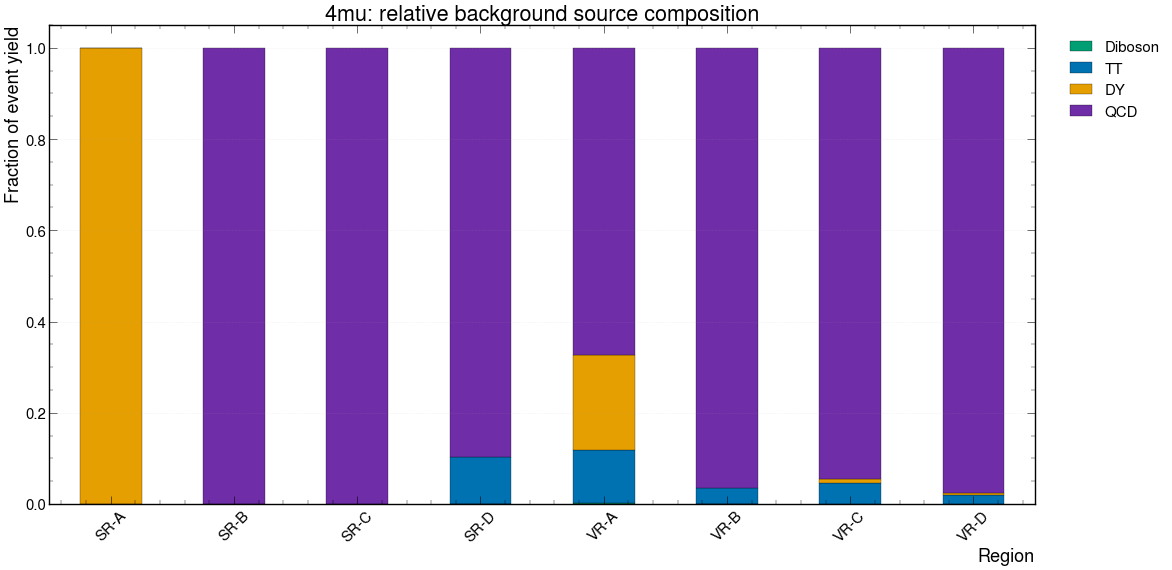

In [7]:
group_landing_fractions = {}
for topology, yield_table in group_landing_yields.items():
    fraction_table = safe_fractions(yield_table)
    group_landing_fractions[topology] = fraction_table
    display(Markdown(f"### {topology}: background-source fractions"))
    display((100 * fraction_table).round(2).astype(str) + "%")
    plot_stacked_table(
        fraction_table,
        f"{topology}: relative background source composition",
        "Fraction of event yield",
        colors=[GROUP_COLORS[group] for group in fraction_table.columns],
    )

In [8]:
def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)
    ratio = np.full(numerator.shape, np.nan, dtype=float)
    error = np.full(numerator.shape, np.nan, dtype=float)
    valid = (
        np.isfinite(numerator) & np.isfinite(numerator_error)
        & np.isfinite(denominator) & np.isfinite(denominator_error)
        & (denominator > 0)
    )
    ratio[valid] = numerator[valid] / denominator[valid]
    positive = valid & (numerator > 0)
    error[positive] = ratio[positive] * np.sqrt(
        (numerator_error[positive] / numerator[positive]) ** 2
        + (denominator_error[positive] / denominator[positive]) ** 2
    )
    zero = valid & (numerator == 0)
    error[zero] = numerator_error[zero] / denominator[zero]
    return ratio, error


def plot_event_signal_background_ratio(table, title):
    x = np.arange(len(table.index))
    fig, (ax, rax) = plt.subplots(
        2, 1, figsize=(24, 12), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )
    for index, process in enumerate(table.index):
        color = GROUP_COLORS[process]
        inclusive = table.loc[process, "Inclusive"]
        inclusive_error = table.loc[process, "Inclusive error"]
        signal_like = table.loc[process, "Signal-like (A)"]
        signal_error = table.loc[process, "Signal-like error"]
        background_like = table.loc[process, "Bkg-like (D)"]
        background_error = table.loc[process, "Bkg-like error"]
        ax.bar(x[index], inclusive, color=color, edgecolor="black", width=0.65, label=process)
        if inclusive > 0:
            ax.errorbar(x[index], inclusive, yerr=inclusive_error, fmt="none", ecolor="black", capsize=4)
        if signal_like > 0:
            ax.errorbar(x[index], signal_like, yerr=signal_error, marker="o", markerfacecolor="none",
                        markeredgecolor="red", ecolor="red", capsize=4, linestyle="none")
        if background_like > 0:
            ax.errorbar(x[index], background_like, yerr=background_error, marker="x",
                        color="blue", ecolor="blue", capsize=4, linestyle="none")
        for value, error, marker, color_name in (
            (table.loc[process, "A / Inclusive"], table.loc[process, "A / Inclusive error"], "o", "red"),
            (table.loc[process, "D / Inclusive"], table.loc[process, "D / Inclusive error"], "x", "blue"),
        ):
            if np.isfinite(value):
                rax.errorbar(x[index], value, yerr=error, marker=marker, markerfacecolor="none" if marker == "o" else color_name,
                             color=color_name, ecolor=color_name, capsize=4, linestyle="none")
    ax.set_yscale("log")
    ax.set(title=title, ylabel="Event yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    from matplotlib.lines import Line2D
    region_handles = [
        Line2D([], [], marker="o", markerfacecolor="none", color="red", linestyle="none", label="Signal-like (A)"),
        Line2D([], [], marker="x", color="blue", linestyle="none", label="Bkg-like (D)"),
    ]
    process_legend = ax.legend(title="Process", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.add_artist(process_legend)
    ax.legend(handles=region_handles, title="Region", bbox_to_anchor=(1.02, 0.55), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Background process", ylim=(0, 1.15))
    rax.set_xticks(x, table.index, rotation=30, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Signal-like and background-like event-yield ratios

Following notebook `02`, `A` (both isolation values pass) is signal-like and `D` (both fail) is background-like. For each SR/VR selection the inclusive denominator is `A+B+C+D`. Error bars use summed histogram variances and the same ratio propagation used in `02`.

### 2mu2e, SR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,26.18924,9.25929,0.00000,0.00000,13.09462,6.54731,0.00000,0.0000,0.50000,0.30619
DY,6.49608,4.59342,6.49608,4.59342,0.00000,0.00000,1.00000,1.0000,0.00000,0.00000
QCD,595.19226,186.91297,95.05890,71.64144,353.25859,156.35302,0.15971,0.1304,0.59352,0.32210


/tmp/ipykernel_7043/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


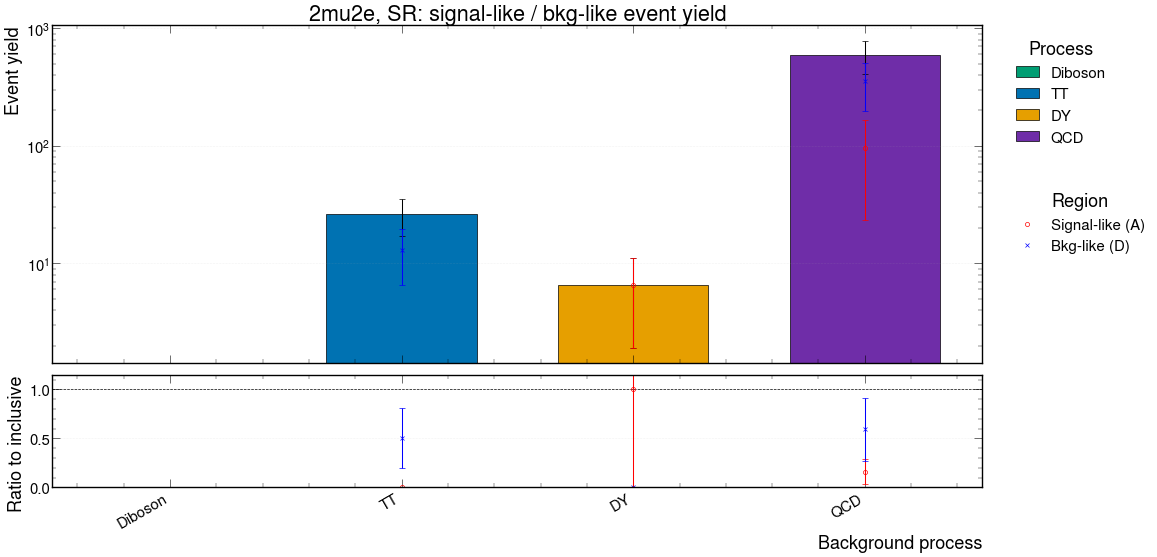

### 2mu2e, VR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,5.23470,1.06566,2.80385,0.80183,0.00000,0.00000,0.53563,0.18802,0.00000,0.00000
TT,1623.73277,72.90775,108.03061,18.80572,566.34228,43.05821,0.06653,0.01196,0.34879,0.03080
DY,118.82246,27.27695,9.74412,5.62577,6.49608,4.59342,0.08201,0.05095,0.05467,0.04064
QCD,4574.29292,701.76719,8.87495,7.38774,3749.40790,671.85320,0.00194,0.00164,0.81967,0.19335


/tmp/ipykernel_7043/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


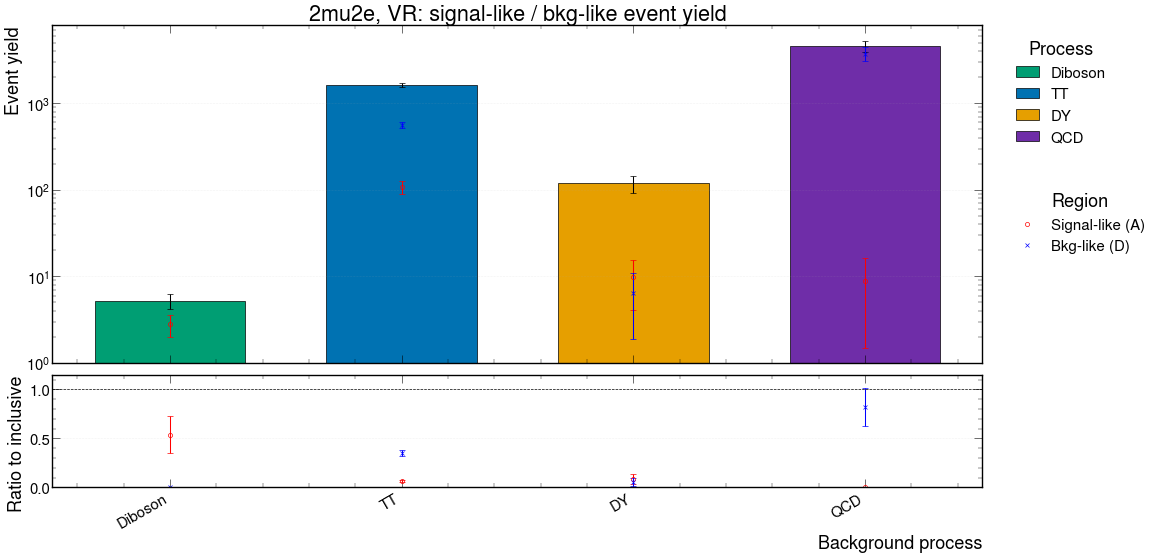

### 4mu, SR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,3.27365,3.27365,0.00000,0.00000,3.27365,3.27365,0.00000,0.00000,1.00000,1.41421
DY,3.24804,3.24804,3.24804,3.24804,0.00000,0.00000,1.00000,1.41421,0.00000,0.00000
QCD,31.39899,10.68955,0.00257,0.00257,28.83799,10.62725,0.00008,0.00009,0.91844,0.46078


/tmp/ipykernel_7043/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


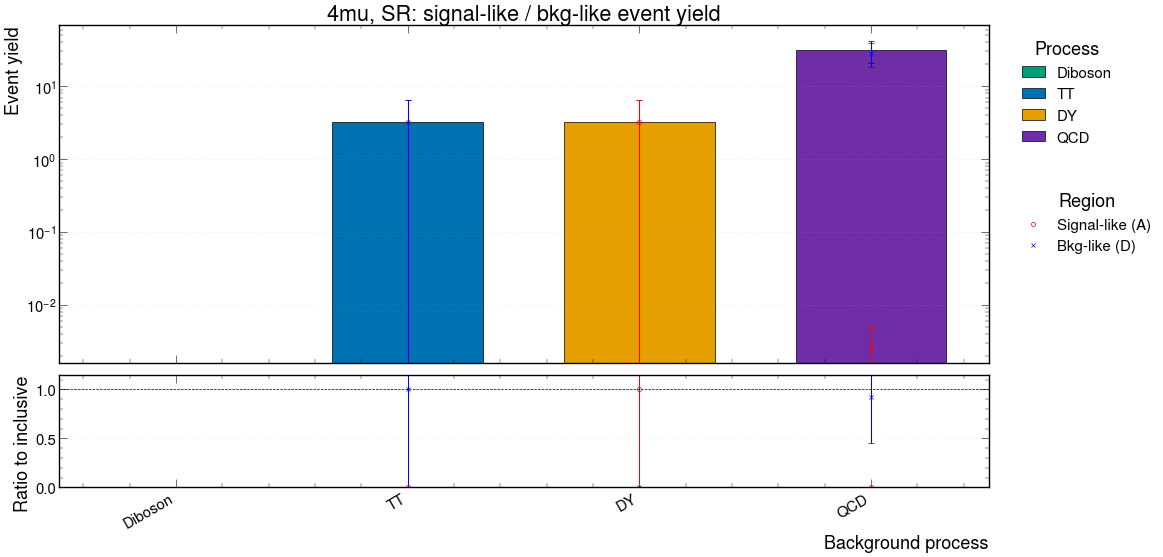

### 4mu, VR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,1.03355,0.46222,0.41342,0.29233,0.41342,0.29233,0.40000,0.33466,0.40000,0.33466
TT,85.11502,16.69243,16.36827,7.32011,39.28386,11.34027,0.19231,0.09391,0.46154,0.16107
DY,38.75064,13.62151,29.00652,12.40550,6.49608,4.59342,0.74854,0.41439,0.16764,0.13238
QCD,2690.40700,368.98307,94.79118,71.64135,1926.83067,294.58498,0.03523,0.02706,0.71619,0.14709


/tmp/ipykernel_7043/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


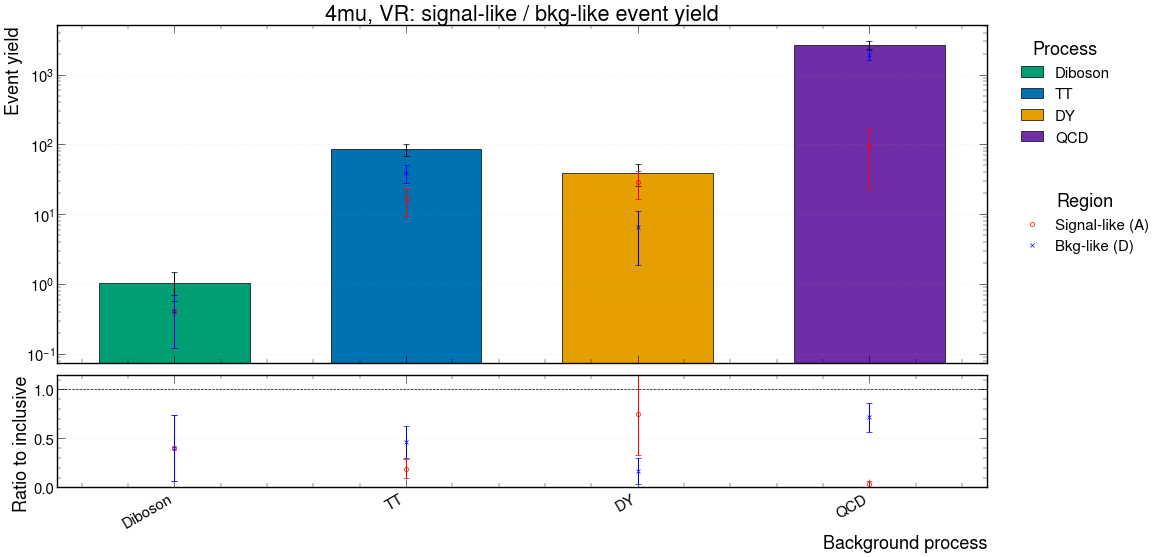

In [9]:
event_region_ratio_tables = {}
for topology in TOPOLOGY_CONFIG:
    event_region_ratio_tables[topology] = {}
    for selection in ("SR", "VR"):
        rows = []
        for group, samples in BACKGROUND_GROUPS.items():
            yields = {}
            variances = {}
            for region in ABCD_REGIONS:
                values = [plane_region_yield(sample, topology, selection, region) for sample in samples]
                yields[region] = sum(value for value, _ in values)
                variances[region] = sum(variance for _, variance in values)
            inclusive = sum(yields.values())
            inclusive_variance = sum(variances.values())
            a_ratio, a_ratio_error = ratio_uncertainty(
                [yields["A"]], [np.sqrt(variances["A"])], [inclusive], [np.sqrt(inclusive_variance)]
            )
            d_ratio, d_ratio_error = ratio_uncertainty(
                [yields["D"]], [np.sqrt(variances["D"])], [inclusive], [np.sqrt(inclusive_variance)]
            )
            rows.append({
                "process": group,
                "Inclusive": inclusive,
                "Inclusive error": np.sqrt(inclusive_variance),
                "Signal-like (A)": yields["A"],
                "Signal-like error": np.sqrt(variances["A"]),
                "Bkg-like (D)": yields["D"],
                "Bkg-like error": np.sqrt(variances["D"]),
                "A / Inclusive": a_ratio[0],
                "A / Inclusive error": a_ratio_error[0],
                "D / Inclusive": d_ratio[0],
                "D / Inclusive error": d_ratio_error[0],
            })
        table = pd.DataFrame(rows).set_index("process")
        event_region_ratio_tables[topology][selection] = table
        display(Markdown(f"### {topology}, {selection}: event yield and A/D ratios"))
        display(table.round(5))
        plot_event_signal_background_ratio(table, f"{topology}, {selection}: signal-like / bkg-like event yield")

## Mother composition by LJ role and ABCD region

All background samples are combined. Numerical mother-object yields are retained in tables, while the region-by-region visualization is shown only as fraction heatmaps. Yield plots are reserved for the later Inclusive/Signal-like/Bkg-like process comparison.

All tables and heatmaps use one common mother-category order determined from the total mother-object yield over every topology, selection, ABCD region, and LJ role.

### Common mother stack order (bottom → top)

,global mother-object yield
Z,141.563330
e,768.441772
$\eta$/$\omega$,942.858132
W,1682.888375
Quark/Gluon,1997.780022
Others,4806.088402
J/$\Psi$,5169.007924
$\pi$,12893.703677
D Meson,16084.182715
B Meson,17871.780638


### 2mu2e, mu-LJ: mother-object yield

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,6.4961,0.0,0.1390,0.0000,15.9776,0.1482,0.1923,160.0437,32.5968,47.6467
SR-B,0.0000,0.0,6.5453,0.0000,4.4573,20.5424,0.1043,105.7280,263.3165,218.0273
SR-C,0.0000,0.0,6.6701,3.2737,1.3277,3.3054,1.3175,34.5644,32.8941,62.1484
SR-D,0.0000,0.0,276.5436,0.0000,40.7591,169.5616,2.9077,304.3577,320.0790,247.9384
VR-A,9.3006,0.0,0.0051,16.3683,32.5709,40.2266,13.0946,17.6645,156.7816,186.1570
VR-B,0.0000,0.0,11.3618,58.9258,46.2586,357.3284,269.5384,247.9110,1320.3113,1127.0168
VR-C,37.7161,0.0,34.5893,115.1980,452.3616,280.5472,147.5309,289.7156,870.0363,881.0815
VR-D,0.0000,0.0,206.5562,58.9258,240.6515,1227.0914,2742.2450,2217.1357,5098.8397,4536.1308


### 2mu2e, mu-LJ: mother composition (%)

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,2.47,0.0,0.05,0.00,6.07,0.06,0.07,60.80,12.38,18.10
SR-B,0.00,0.0,1.06,0.00,0.72,3.32,0.02,17.09,42.56,35.24
SR-C,0.00,0.0,4.58,2.25,0.91,2.27,0.91,23.76,22.61,42.71
SR-D,0.00,0.0,20.30,0.00,2.99,12.45,0.21,22.34,23.50,18.20
VR-A,1.97,0.0,0.00,3.47,6.90,8.52,2.77,3.74,33.20,39.43
VR-B,0.00,0.0,0.33,1.71,1.35,10.39,7.84,7.21,38.40,32.77
VR-C,1.21,0.0,1.11,3.71,14.55,9.02,4.75,9.32,27.99,28.34
VR-D,0.00,0.0,1.27,0.36,1.47,7.52,16.80,13.58,31.23,27.78


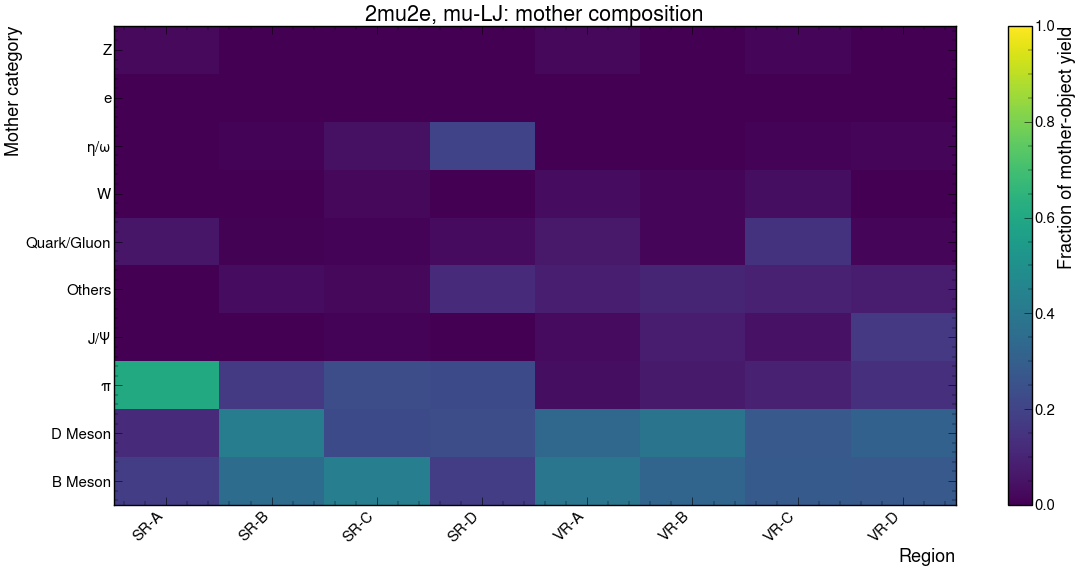

### 2mu2e, egm-LJ: mother-object yield

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,0.0000,0.0000,3.2480,0.0000,9.6657,7.9914,0.0000,30.1904,0.0000,0.0000
SR-B,0.0000,0.0000,0.3905,3.2737,26.1027,15.8345,0.0000,316.9496,0.0480,0.0583
SR-C,0.0000,0.0000,10.6887,0.0000,8.0334,0.1519,0.0000,76.0443,8.0519,0.0703
SR-D,0.0000,0.0000,90.9736,0.0000,26.1730,9.9728,0.0000,746.1592,0.2321,25.8020
VR-A,11.3283,53.5783,0.0000,105.7799,7.3378,11.5051,0.0000,8.1315,1.3175,1.5338
VR-B,6.4961,376.6514,0.2134,727.1648,113.4413,133.4906,0.0051,34.1447,13.6930,11.9647
VR-C,4.4386,72.9729,36.0177,108.4440,51.2000,106.5268,7.3275,1092.6640,433.9218,641.8816
VR-D,6.4961,265.2391,100.8106,425.5751,221.5460,430.8156,261.5146,2774.5882,941.1566,3925.5460


### 2mu2e, egm-LJ: mother composition (%)

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,0.00,0.00,6.36,0.00,18.92,15.64,0.00,59.09,0.00,0.00
SR-B,0.00,0.00,0.11,0.90,7.20,4.37,0.00,87.40,0.01,0.02
SR-C,0.00,0.00,10.37,0.00,7.80,0.15,0.00,73.80,7.81,0.07
SR-D,0.00,0.00,10.12,0.00,2.91,1.11,0.00,82.97,0.03,2.87
VR-A,5.65,26.72,0.00,52.75,3.66,5.74,0.00,4.06,0.66,0.76
VR-B,0.46,26.58,0.02,51.31,8.00,9.42,0.00,2.41,0.97,0.84
VR-C,0.17,2.86,1.41,4.24,2.00,4.17,0.29,42.76,16.98,25.12
VR-D,0.07,2.84,1.08,4.55,2.37,4.61,2.80,29.66,10.06,41.97


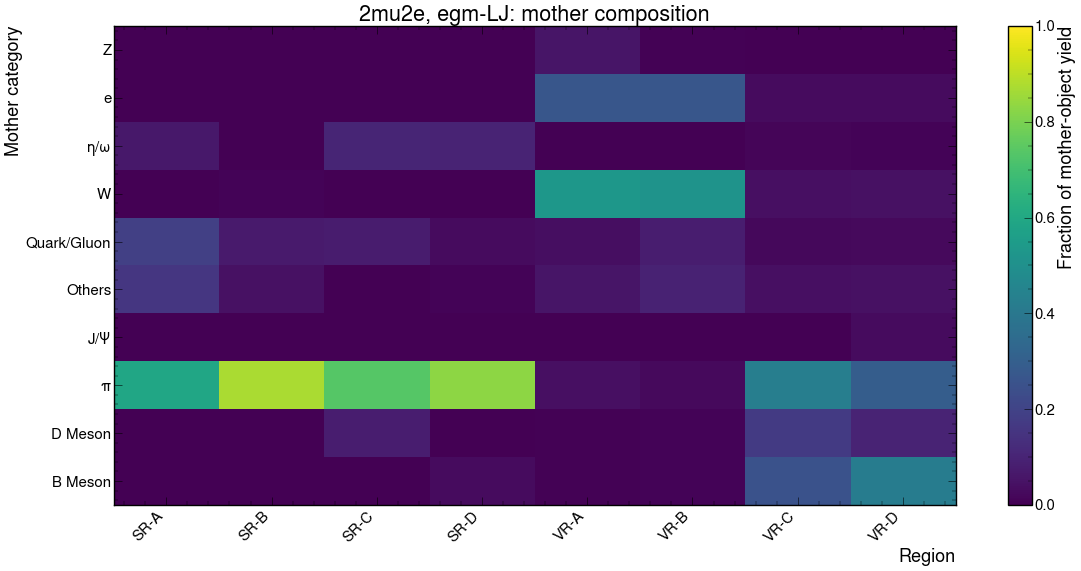

### 4mu, leading mu-LJ: mother-object yield

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,3.2480,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SR-B,0.0000,0.0,0.0068,0.0000,0.0343,0.0051,0.0051,0.3494,1.4067,0.0789
SR-C,0.0000,0.0,0.0248,0.0000,0.1897,0.2142,0.0000,1.5231,1.8013,2.0190
SR-D,0.0000,0.0,4.2109,0.0000,3.7342,4.4673,0.0976,85.4978,42.0445,16.0881
VR-A,19.9017,0.0,0.0000,16.3683,19.0366,42.1097,141.1847,151.4320,54.8709,48.3774
VR-B,0.0000,0.0,19.0577,0.0000,2.6210,56.3339,514.1251,157.8785,112.1865,115.4679
VR-C,3.2480,0.0,1.2324,23.7424,180.2388,75.2458,50.6705,185.3092,415.9354,552.5141
VR-D,0.0000,0.0,49.3194,3.2737,311.0251,932.0217,407.8379,1547.6061,2305.7792,1996.2257


### 4mu, leading mu-LJ: mother composition (%)

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,100.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SR-B,0.00,0.0,0.36,0.00,1.82,0.27,0.27,18.52,74.57,4.18
SR-C,0.00,0.0,0.43,0.00,3.29,3.71,0.00,26.39,31.21,34.98
SR-D,0.00,0.0,2.70,0.00,2.39,2.86,0.06,54.76,26.93,10.30
VR-A,4.03,0.0,0.00,3.32,3.86,8.54,28.62,30.70,11.12,9.81
VR-B,0.00,0.0,1.95,0.00,0.27,5.76,52.59,16.15,11.47,11.81
VR-C,0.22,0.0,0.08,1.60,12.11,5.06,3.40,12.45,27.95,37.13
VR-D,0.00,0.0,0.65,0.04,4.12,12.34,5.40,20.49,30.53,26.43


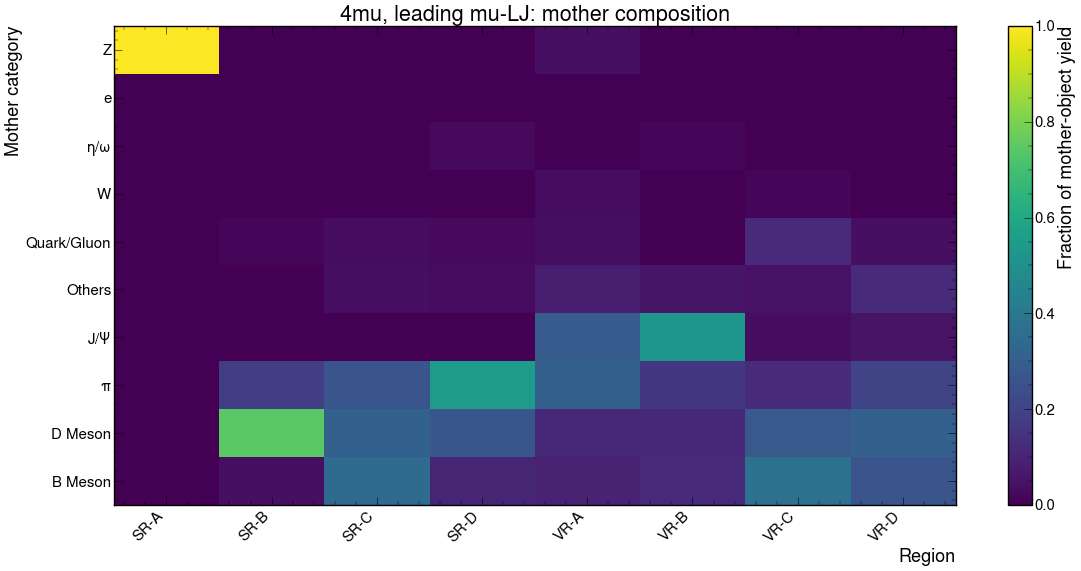

### 4mu, subleading mu-LJ: mother-object yield

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,3.2480,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SR-B,0.0000,0.0,0.0026,0.0000,0.0119,0.0026,0.0000,0.1536,1.4101,1.3809
SR-C,0.0000,0.0,0.0214,0.0000,0.0326,0.1919,0.0000,6.9794,0.4551,1.6640
SR-D,0.0000,0.0,11.8324,0.0000,16.9068,6.4096,0.0051,87.2188,27.8283,6.5321
VR-A,23.1497,0.0,0.0000,6.5473,9.5183,47.6686,6.5473,0.2661,65.9848,50.6617
VR-B,0.0000,0.0,4.0164,6.5473,8.1351,140.1921,238.4777,45.9017,100.3303,258.9644
VR-C,0.0000,0.0,11.3497,0.2067,26.0960,101.5052,21.3662,373.5026,735.6161,602.6621
VR-D,6.4961,0.0,57.0309,3.2737,122.3354,584.6807,342.9127,1794.0930,2725.2573,2306.1406


### 4mu, subleading mu-LJ: mother composition (%)

,Z,e,$\eta$/$\omega$,W,Quark/Gluon,Others,J/$\Psi$,$\pi$,D Meson,B Meson
region,,,,,,,,,,
SR-A,100.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SR-B,0.00,0.0,0.09,0.00,0.40,0.09,0.00,5.19,47.61,46.63
SR-C,0.00,0.0,0.23,0.00,0.35,2.05,0.00,74.69,4.87,17.81
SR-D,0.00,0.0,7.55,0.00,10.79,4.09,0.00,55.65,17.76,4.17
VR-A,11.01,0.0,0.00,3.11,4.53,22.66,3.11,0.13,31.37,24.09
VR-B,0.00,0.0,0.50,0.82,1.01,17.47,29.71,5.72,12.50,32.27
VR-C,0.00,0.0,0.61,0.01,1.39,5.42,1.14,19.95,39.29,32.19
VR-D,0.08,0.0,0.72,0.04,1.54,7.36,4.32,22.59,34.31,29.04


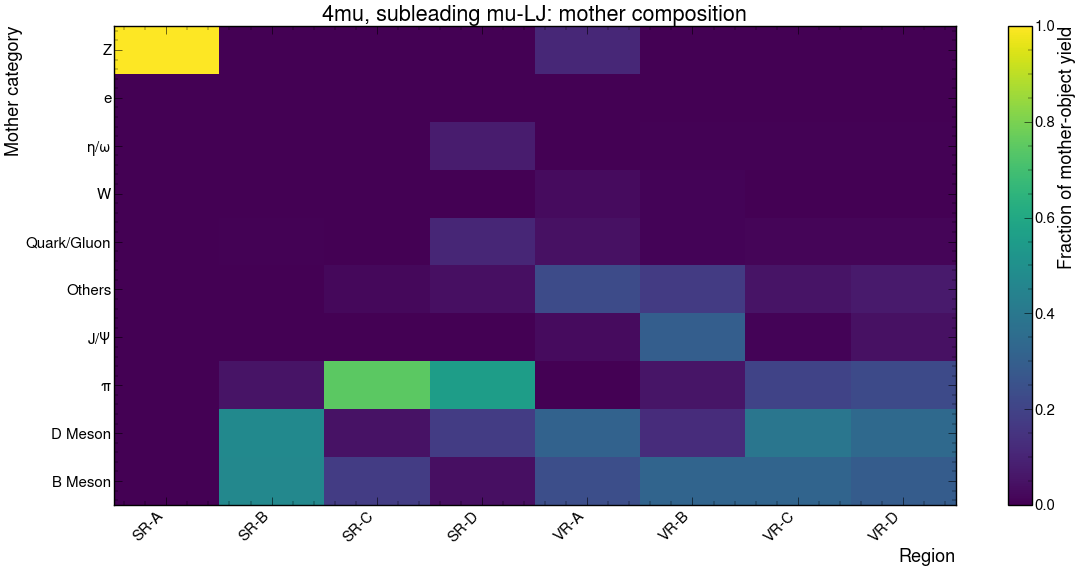

In [10]:
mother_yields = {}
mother_errors = {}
mother_fractions = {}

# First pass: build every yield table before choosing one global stack order.
for topology, config in TOPOLOGY_CONFIG.items():
    mother_yields[topology] = {}
    mother_errors[topology] = {}
    mother_fractions[topology] = {}
    for role in config["roles"]:
        yield_rows = []
        variance_rows = []
        for selection in ("SR", "VR"):
            for region in ABCD_REGIONS:
                label = f"{selection}-{region}"
                category_yields = defaultdict(float)
                category_variances = defaultdict(float)
                for sample in SAMPLES:
                    histogram = mother_histogram(sample, topology, role, selection, region)
                    sample_yields, sample_variances = categorize_mother_histogram(histogram)
                    for category in MOTHER_CATEGORY_ORDER:
                        category_yields[category] += sample_yields[category]
                        category_variances[category] += sample_variances[category]
                yield_rows.append({"region": label, **category_yields})
                variance_rows.append({"region": label, **category_variances})

        yield_table = pd.DataFrame(yield_rows).set_index("region").reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        variance_table = pd.DataFrame(variance_rows).set_index("region").reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        mother_yields[topology][role] = yield_table
        mother_errors[topology][role] = np.sqrt(variance_table)

# Use one common bottom-to-top order: lowest global yield first.
global_mother_yield = pd.Series(0.0, index=MOTHER_CATEGORY_ORDER)
for topology_tables in mother_yields.values():
    for yield_table in topology_tables.values():
        global_mother_yield = global_mother_yield.add(yield_table.sum(axis=0), fill_value=0.0)
MOTHER_STACK_ORDER = global_mother_yield.sort_values(kind="stable").index.tolist()

display(Markdown("### Common mother stack order (bottom → top)"))
display(global_mother_yield.reindex(MOTHER_STACK_ORDER).rename("global mother-object yield").to_frame())

# Second pass: use the same order in every yield stack and composition heatmap.
for topology, config in TOPOLOGY_CONFIG.items():
    for role in config["roles"]:
        yield_table = mother_yields[topology][role].reindex(columns=MOTHER_STACK_ORDER)
        error_table = mother_errors[topology][role].reindex(columns=MOTHER_STACK_ORDER)
        fraction_table = safe_fractions(yield_table)
        mother_yields[topology][role] = yield_table
        mother_errors[topology][role] = error_table
        mother_fractions[topology][role] = fraction_table

        display(Markdown(f"### {topology}, {role}: mother-object yield"))
        display(yield_table.round(4))
        display(Markdown(f"### {topology}, {role}: mother composition (%)"))
        display((100 * fraction_table).round(2))
        plot_fraction_heatmap(
            fraction_table,
            f"{topology}, {role}: mother composition",
        )

## Mother yield resolved by background source

The nested tables below retain the full `(background group, mother category)` breakdown for every topology, LJ role, and region.

In [11]:
mother_yields_by_source = {}

for topology, config in TOPOLOGY_CONFIG.items():
    mother_yields_by_source[topology] = {}
    for role in config["roles"]:
        rows = []
        for selection in ("SR", "VR"):
            for region in ABCD_REGIONS:
                label = f"{selection}-{region}"
                row = {"region": label}
                for group, samples in BACKGROUND_GROUPS.items():
                    grouped_yields = defaultdict(float)
                    for sample in samples:
                        histogram = mother_histogram(sample, topology, role, selection, region)
                        sample_yields, _ = categorize_mother_histogram(histogram)
                        for category in MOTHER_CATEGORY_ORDER:
                            grouped_yields[category] += sample_yields[category]
                    for category in MOTHER_CATEGORY_ORDER:
                        row[(group, category)] = grouped_yields[category]
                rows.append(row)

        table = pd.DataFrame(rows).set_index("region")
        table.columns = pd.MultiIndex.from_tuples(table.columns, names=["background", "mother"])
        mother_yields_by_source[topology][role] = table
        display(Markdown(f"### {topology}, {role}: background × mother yield"))
        display(table.round(4))

### 2mu2e, mu-LJ: background × mother yield

background Diboson                                                       \
mother           Z       W    e   $\pi$ $\eta$/$\omega$ B Meson D Meson   
region                                                                    
SR-A        0.0000  0.0000  0.0  0.0000             0.0  0.0000  0.0000   
SR-B        0.0000  0.0000  0.0  0.0000             0.0  0.0000  0.0000   
SR-C        0.0000  0.0000  0.0  0.0000             0.0  0.0000  0.0000   
SR-D        0.0000  0.0000  0.0  0.0000             0.0  0.0000  0.0000   
VR-A        2.8045  0.0000  0.0  0.4134             0.0  0.0000  0.0000   
VR-B        0.0000  0.0000  0.0  0.2067             0.0  0.8268  0.8268   
VR-C        1.9876  0.6201  0.0  0.0000             0.0  0.0000  0.0000   
VR-D        0.0000  0.0000  0.0  0.0000             0.0  0.0000  0.0000   

background                                TT                           \
mother     Quark/Gluon J/$\Psi$  Others    Z         W    e     $\pi$   
region                                                                  
SR-A               0.0      0.0  0.0000  0.0    0.0000  0.0    0.0000   
SR-B               0.0      0.0  0.0000  0.0    0.0000  0.0    0.0000   
SR-C               0.0      0.0  0.0000  0.0    3.2737  0.0    3.2737   
SR-D               0.0      0.0  0.0000  0.0    0.0000  0.0    6.5473   
VR-A               0.0      0.0  1.0037  0.0   16.3683  0.0   16.3683   
VR-B               0.0      0.0  0.0000  0.0   58.9258  0.0  209.5139   
VR-C               0.0      0.0  2.2241  0.0  114.5779  0.0    6.5473   
VR-D               0.0      0.0  0.0000  0.0   58.9258  0.0  176.7774   

background                                                              \
mother     $\eta$/$\omega$    B Meson    D Meson Quark/Gluon  J/$\Psi$   
region                                                                   
SR-A                0.0000     0.0000     0.0000      0.0000    0.0000   
SR-B                0.0000     6.5473    13.0946      0.0000    0.0000   
SR-C                6.5473     0.0000     0.0000      0.0000    0.0000   
SR-D                0.0000    13.0946    26.1892      0.0000    0.0000   
VR-A                0.0000   183.3247   153.8618      0.0000   13.0946   
VR-B                9.8210  1086.8534  1099.9480     39.2839  229.1558   
VR-C                9.8210   199.6929   183.3247      0.0000   39.2839   
VR-D               16.3683   766.0352   808.5927     39.2839  183.3247   

background                 DY                                           \
mother        Others        Z    W    e $\pi$ $\eta$/$\omega$  B Meson   
region                                                                   
SR-A          0.0000   6.4961  0.0  0.0   0.0             0.0   0.0000   
SR-B          9.8210   0.0000  0.0  0.0   0.0             0.0   0.0000   
SR-C          3.2737   0.0000  0.0  0.0   0.0             0.0   0.0000   
SR-D          0.0000   0.0000  0.0  0.0   0.0             0.0   0.0000   
VR-A         19.6419   6.4961  0.0  0.0   0.0             0.0   0.0000   
VR-B        140.7672   0.0000  0.0  0.0   0.0             0.0  12.9922   
VR-C         98.2096  35.7284  0.0  0.0   0.0             0.0   0.0000   
VR-D        157.1354   0.0000  0.0  0.0   0.0             0.0   6.4961   

background                                         QCD                       \
mother      D Meson Quark/Gluon J/$\Psi$   Others    Z    W    e      $\pi$   
region                                                                        
SR-A         0.0000      0.0000   0.0000   0.0000  0.0  0.0  0.0   160.0437   
SR-B         0.0000      0.0000   0.0000   0.0000  0.0  0.0  0.0   105.7280   
SR-C         0.0000      0.0000   0.0000   0.0000  0.0  0.0  0.0    31.2908   
SR-D         0.0000      0.0000   0.0000   0.0000  0.0  0.0  0.0   297.8104   
VR-A         0.0000      3.2480   0.0000  19.4882  0.0  0.0  0.0     0.8828   
VR-B        16.2402      6.4961  25.5326   0.0000  0.0  0.0  0.0    38.1904   
VR-C         3.2480     95.18

### 2mu2e, egm-LJ: background × mother yield

background Diboson                                                          \
mother           Z       W       e   $\pi$ $\eta$/$\omega$ B Meson D Meson   
region                                                                       
SR-A        0.0000  0.0000  0.0000  0.0000             0.0     0.0     0.0   
SR-B        0.0000  0.0000  0.0000  0.0000             0.0     0.0     0.0   
SR-C        0.0000  0.0000  0.0000  0.0000             0.0     0.0     0.0   
SR-D        0.0000  0.0000  0.0000  0.0000             0.0     0.0     0.0   
VR-A        1.5841  1.0229  1.1998  0.4134             0.0     0.0     0.0   
VR-B        0.0000  0.4134  0.2067  0.0000             0.0     0.0     0.0   
VR-C        1.1906  0.4134  1.0037  0.3935             0.0     0.0     0.0   
VR-D        0.0000  0.0000  0.0000  0.0000             0.0     0.0     0.0   

background                                TT                               \
mother     Quark/Gluon J/$\Psi$  Others    Z         W         e    $\pi$   
region                                                                      
SR-A               0.0      0.0  0.0000  0.0    0.0000    0.0000   0.0000   
SR-B               0.0      0.0  0.0000  0.0    3.2737    0.0000   0.0000   
SR-C               0.0      0.0  0.0000  0.0    0.0000    0.0000   0.0000   
SR-D               0.0      0.0  0.0000  0.0    0.0000    0.0000  13.0946   
VR-A               0.0      0.0  1.5941  0.0  104.7570   52.3785   0.0000   
VR-B               0.0      0.0  0.0000  0.0  726.7514  373.1966   6.5473   
VR-C               0.0      0.0  1.4271  0.0  108.0306   65.4731  55.6521   
VR-D               0.0      0.0  0.0000  0.0  425.5751  261.8924  94.9360   

background                                                                   \
mother     $\eta$/$\omega$  B Meson  D Meson Quark/Gluon J/$\Psi$    Others   
region                                                                        
SR-A                0.0000   0.0000   0.0000      0.0000   0.0000    0.0000   
SR-B                0.0000   0.0000   0.0000      0.0000   0.0000    0.0000   
SR-C                3.2737   0.0000   6.5473      0.0000   0.0000    0.0000   
SR-D                0.0000   6.5473   0.0000      3.2737   0.0000    0.0000   
VR-A                0.0000   0.0000   0.0000      0.0000   0.0000    9.8210   
VR-B                0.0000   6.5473   9.8210     22.9156   0.0000  124.3989   
VR-C                0.0000  94.9360  36.0102      3.2737   0.0000   32.7365   
VR-D                6.5473  62.1994  36.0102     22.9156   3.2737  127.6725   

background      DY                                                         \
mother           Z    W       e    $\pi$ $\eta$/$\omega$  B Meson D Meson   
region                                                                      
SR-A        0.0000  0.0  0.0000   0.0000           3.248   0.0000     0.0   
SR-B        0.0000  0.0  0.0000   0.0000           0.000   0.0000     0.0   
SR-C        0.0000  0.0  0.0000   0.0000           0.000   0.0000     0.0   
SR-D        0.0000  0.0  0.0000   0.0000           0.000   0.0000     0.0   
VR-A        9.7441  0.0  0.0000   0.0000           0.000   0.0000     0.0   
VR-B        6.4961  0.0  3.2480   6.4961           0.000   0.0000     0.0   
VR-C        3.2480  0.0  6.4961  35.5026           0.000  32.0287     0.0   
VR-D        6.4961  0.0  3.2480   0.0000           0.000   0.0000     0.0   

background                               QCD                          \
mother     Quark/Gluon J/$\Psi$  Others    Z    W       e      $\pi$   
region                                                                 
SR-A            0.0000      0.0  0.0000  0.0  0.0  0.0000    30.1904   
SR-B            0.0000      0.0  0.0000  0.0  0.0  0.0000   316.9496   
SR-C            0.0000      0.0  0.0000  0.0  0.0  0.0000    76.0443   
SR-D            0.0000      0.0  0.0000  0.0  0.0  0.0000   733.0646   
VR-A            0.0000      0.0  0.0000  0.0  0.0  0.0000     7.7180   

### 4mu, leading mu-LJ: background × mother yield

background Diboson                                                     \
mother           Z       W    e $\pi$ $\eta$/$\omega$ B Meson D Meson   
region                                                                  
SR-A        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-B        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-C        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-D        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-A        0.4134  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-B        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-C        0.0000  0.8268  0.0   0.0             0.0  0.4134  0.4134   
VR-D        0.0000  0.0000  0.0   0.0             0.0  0.8268  0.4134   

background                                TT                         \
mother     Quark/Gluon J/$\Psi$  Others    Z        W    e    $\pi$   
region                                                                
SR-A               0.0      0.0  0.0000  0.0   0.0000  0.0   0.0000   
SR-B               0.0      0.0  0.0000  0.0   0.0000  0.0   0.0000   
SR-C               0.0      0.0  0.0000  0.0   0.0000  0.0   0.0000   
SR-D               0.0      0.0  0.0000  0.0   0.0000  0.0  13.0946   
VR-A               0.0      0.0  0.2067  0.0  16.3683  0.0   0.0000   
VR-B               0.0      0.0  0.0000  0.0   0.0000  0.0  26.1892   
VR-C               0.0      0.0  0.0000  0.0  22.9156  0.0   0.0000   
VR-D               0.0      0.0  0.0000  0.0   3.2737  0.0  19.6419   

background                                                                  \
mother     $\eta$/$\omega$  B Meson  D Meson Quark/Gluon J/$\Psi$   Others   
region                                                                       
SR-A                0.0000   0.0000   0.0000       0.000   0.0000   0.0000   
SR-B                0.0000   0.0000   0.0000       0.000   0.0000   0.0000   
SR-C                0.0000   0.0000   0.0000       0.000   0.0000   0.0000   
SR-D                0.0000   6.5473   6.5473       0.000   0.0000   0.0000   
VR-A                0.0000   0.0000   0.0000       0.000   0.0000   9.8210   
VR-B                9.8210   6.5473  19.6419       0.000   0.0000   3.2737   
VR-C                0.0000   6.5473   6.5473       0.000   3.2737  16.3683   
VR-D                3.2737  26.1892  58.9258       9.821   6.5473  26.1892   

background       DY                                                   \
mother            Z    W    e $\pi$ $\eta$/$\omega$ B Meson  D Meson   
region                                                                 
SR-A         3.2480  0.0  0.0   0.0             0.0     0.0   0.0000   
SR-B         0.0000  0.0  0.0   0.0             0.0     0.0   0.0000   
SR-C         0.0000  0.0  0.0   0.0             0.0     0.0   0.0000   
SR-D         0.0000  0.0  0.0   0.0             0.0     0.0   0.0000   
VR-A        19.4882  0.0  0.0   0.0             0.0     0.0   6.4961   
VR-B         0.0000  0.0  0.0   0.0             0.0     0.0   0.0000   
VR-C         3.2480  0.0  0.0   0.0             0.0     0.0   0.0000   
VR-D         0.0000  0.0  0.0   0.0             0.0     0.0  12.9922   

background                                QCD                       \
mother     Quark/Gluon J/$\Psi$   Others    Z    W    e      $\pi$   
region                                                               
SR-A            0.0000   0.0000   0.0000  0.0  0.0  0.0     0.0000   
SR-B            0.0000   0.0000   0.0000  0.0  0.0  0.0     0.3494   
SR-C            0.0000   0.0000   0.0000  0.0  0.0  0.0     1.5231   
SR-D            0.0000   0.0000   0.0000  0.0  0.0  0.0    72.4031   
VR-A           19.0366   0.0000  28.7807  0.0  0.0  0.0   151.4320   
VR-B            0.0000   0.0000   0.0000  0.0  0.0  0.0   131.6892   
VR-C            0.0000   0.0000   0.0000  0.0  0.0  0.0   185.3092   
VR-D            0.0000   6.4961   0.0000  0.0  0.0  0.0  1527.

### 4mu, subleading mu-LJ: background × mother yield

background Diboson                                                     \
mother           Z       W    e $\pi$ $\eta$/$\omega$ B Meson D Meson   
region                                                                  
SR-A        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-B        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-C        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
SR-D        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-A        0.4134  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-B        0.0000  0.0000  0.0   0.0             0.0  0.0000  0.0000   
VR-C        0.0000  0.2067  0.0   0.0             0.0  0.8268  0.8268   
VR-D        0.0000  0.0000  0.0   0.0             0.0  0.8268  0.8268   

background                                TT                      \
mother     Quark/Gluon J/$\Psi$  Others    Z       W    e  $\pi$   
region                                                             
SR-A               0.0      0.0  0.0000  0.0  0.0000  0.0  0.000   
SR-B               0.0      0.0  0.0000  0.0  0.0000  0.0  0.000   
SR-C               0.0      0.0  0.0000  0.0  0.0000  0.0  0.000   
SR-D               0.0      0.0  0.0000  0.0  0.0000  0.0  0.000   
VR-A               0.0      0.0  0.6201  0.0  6.5473  0.0  0.000   
VR-B               0.0      0.0  0.0000  0.0  6.5473  0.0  0.000   
VR-C               0.0      0.0  0.0000  0.0  0.0000  0.0  9.821   
VR-D               0.0      0.0  0.0000  0.0  3.2737  0.0  0.000   

background                                                                  \
mother     $\eta$/$\omega$  B Meson  D Meson Quark/Gluon J/$\Psi$   Others   
region                                                                       
SR-A                 0.000   0.0000   0.0000      0.0000   0.0000   0.0000   
SR-B                 0.000   0.0000   0.0000      0.0000   0.0000   0.0000   
SR-C                 0.000   0.0000   0.0000      0.0000   0.0000   0.0000   
SR-D                 0.000   0.0000   9.8210      0.0000   0.0000   0.0000   
VR-A                 0.000  19.6419  19.6419      0.0000   6.5473   6.5473   
VR-B                 0.000   0.0000   0.0000      3.2737   0.0000   9.8210   
VR-C                 0.000  42.5575  26.1892      0.0000   6.5473   0.0000   
VR-D                 9.821  45.8312  32.7365      0.0000   6.5473  16.3683   

background       DY                                                   \
mother            Z    W    e  $\pi$ $\eta$/$\omega$ B Meson D Meson   
region                                                                 
SR-A         3.2480  0.0  0.0  0.000           0.000     0.0  0.0000   
SR-B         0.0000  0.0  0.0  0.000           0.000     0.0  0.0000   
SR-C         0.0000  0.0  0.0  0.000           0.000     0.0  0.0000   
SR-D         0.0000  0.0  0.0  0.000           0.000     0.0  0.0000   
VR-A        22.7363  0.0  0.0  0.000           0.000     0.0  6.4961   
VR-B         0.0000  0.0  0.0  0.000           0.000     0.0  0.0000   
VR-C         0.0000  0.0  0.0  0.000           0.000     0.0  0.0000   
VR-D         6.4961  0.0  0.0  3.248           3.248     0.0  6.4961   

background                               QCD                       \
mother     Quark/Gluon J/$\Psi$  Others    Z    W    e      $\pi$   
region                                                              
SR-A            0.0000      0.0  0.0000  0.0  0.0  0.0     0.0000   
SR-B            0.0000      0.0  0.0000  0.0  0.0  0.0     0.1536   
SR-C            0.0000      0.0  0.0000  0.0  0.0  0.0     6.9794   
SR-D            0.0000      0.0  0.0000  0.0  0.0  0.0    87.2188   
VR-A            9.5183      0.0  9.7441  0.0  0.0  0.0     0.2661   
VR-B            0.0000      0.0  0.0000  0.0  0.0  0.0    45.9017   
VR-C            0.0000      0.0  0.0000  0.0  0.0  0.0   363.6817   
VR-D            0.0000      0.0  0.0000  0.0  0.0  0.0  1790.8449   

background                         

## Process-resolved mother yield with signal-like/background-like ratios

This is the direct ABCD analogue of the process overlay in notebook `02`. For each SR/VR selection and LJ role, the bar is the inclusive mother-object yield (`A+B+C+D`), while the red circle and blue cross show signal-like `A` and background-like `D`. The lower panel shows their ratios to inclusive. Error bars are propagated from histogram variances.

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


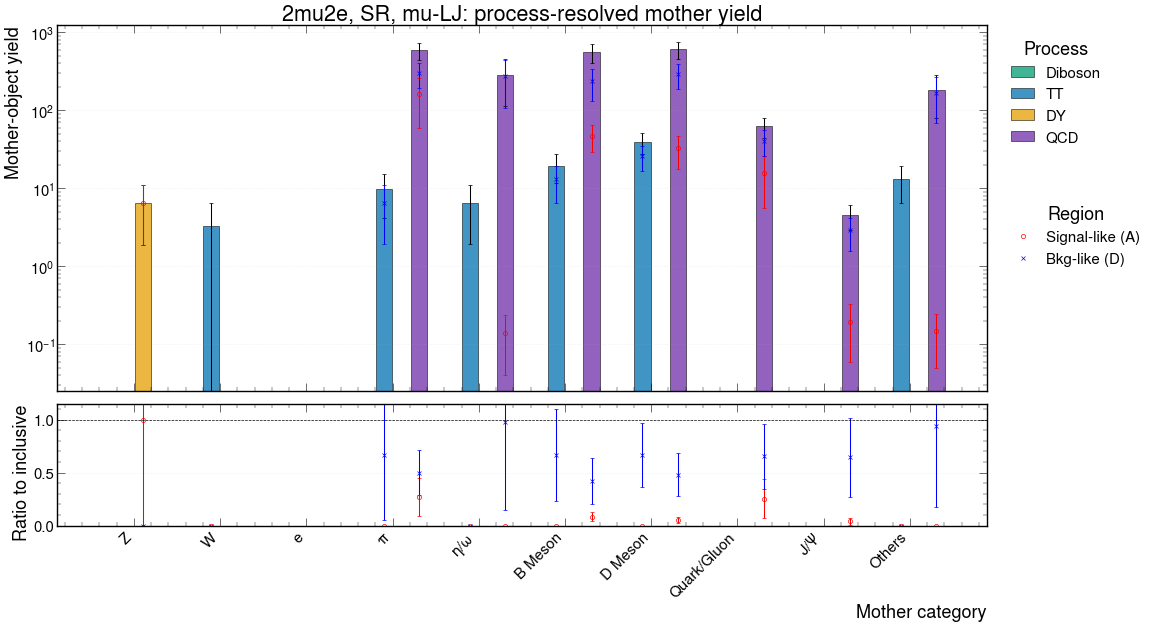

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


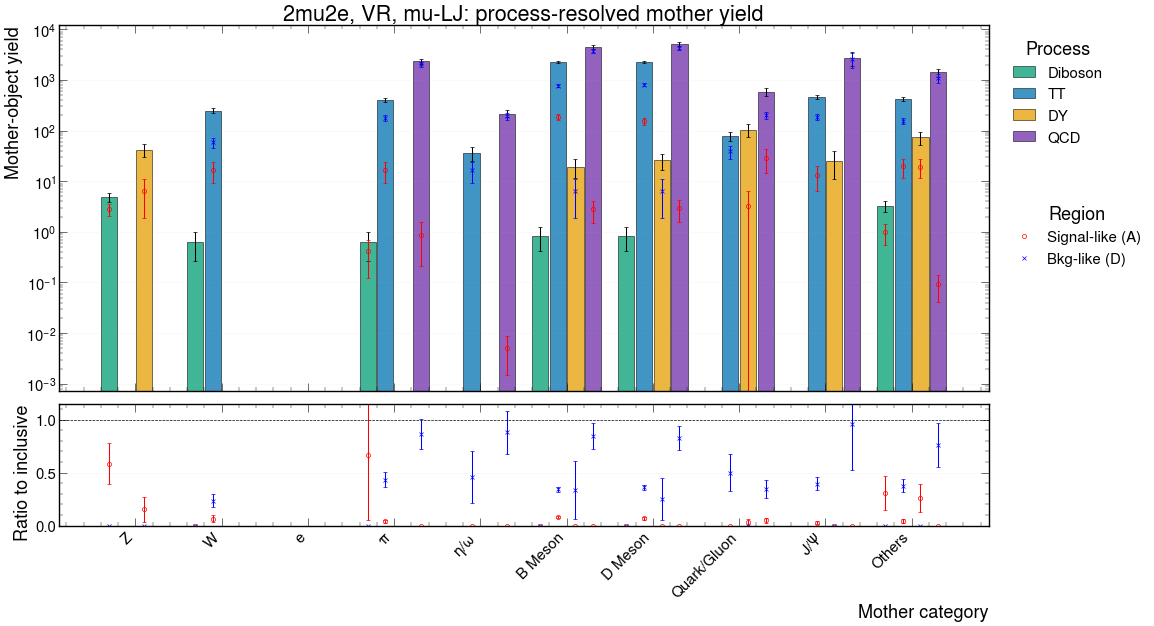

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


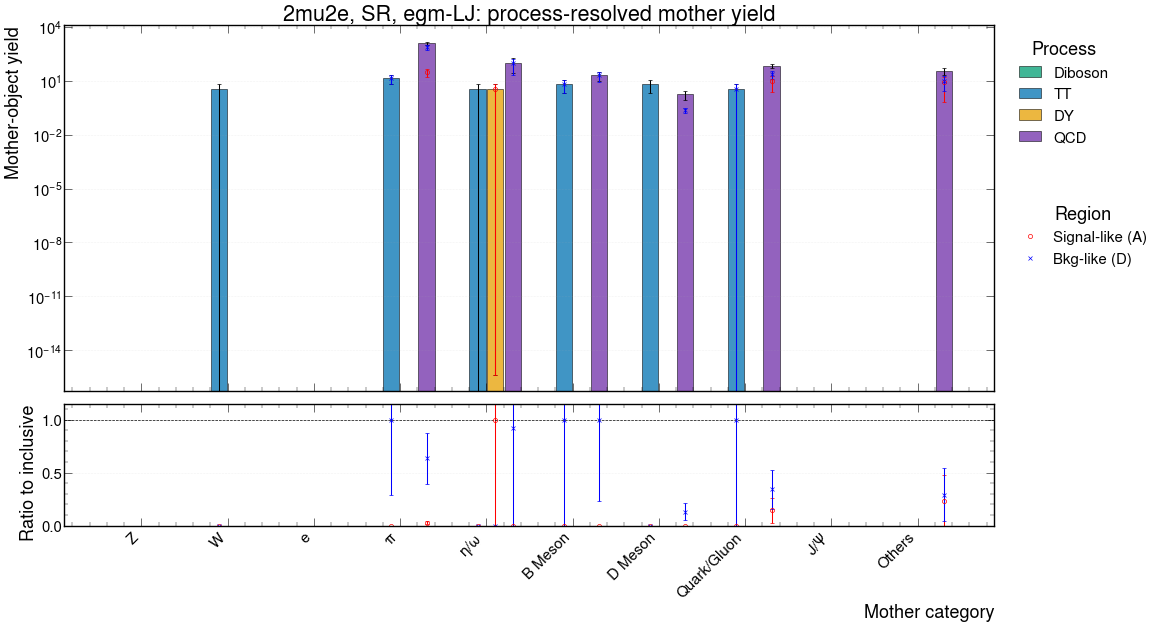

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


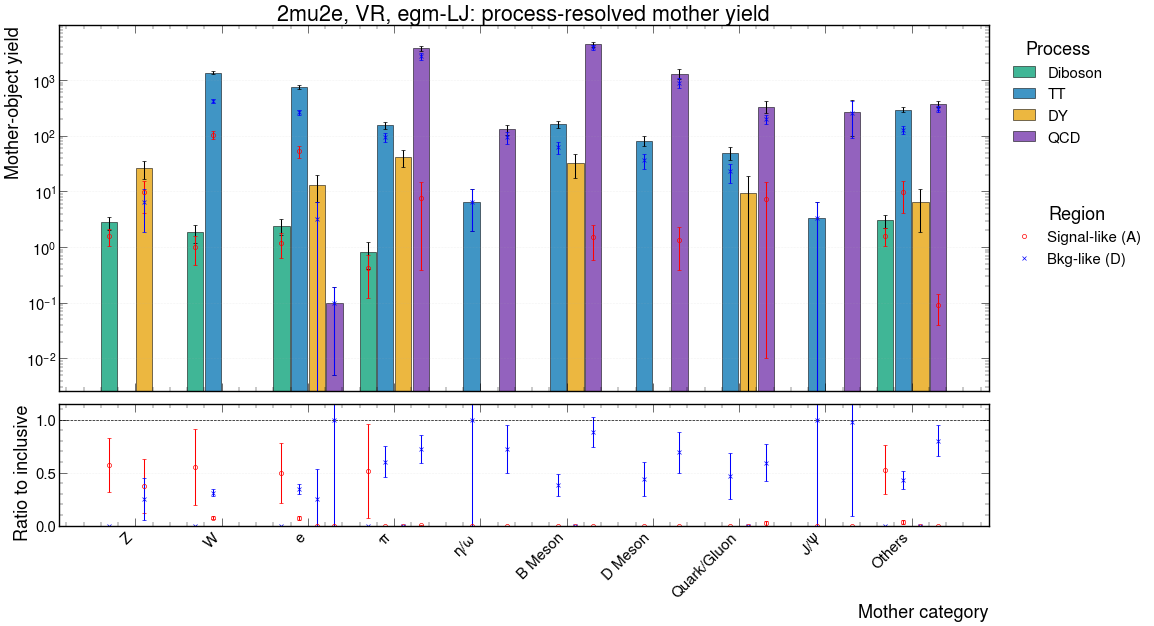

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


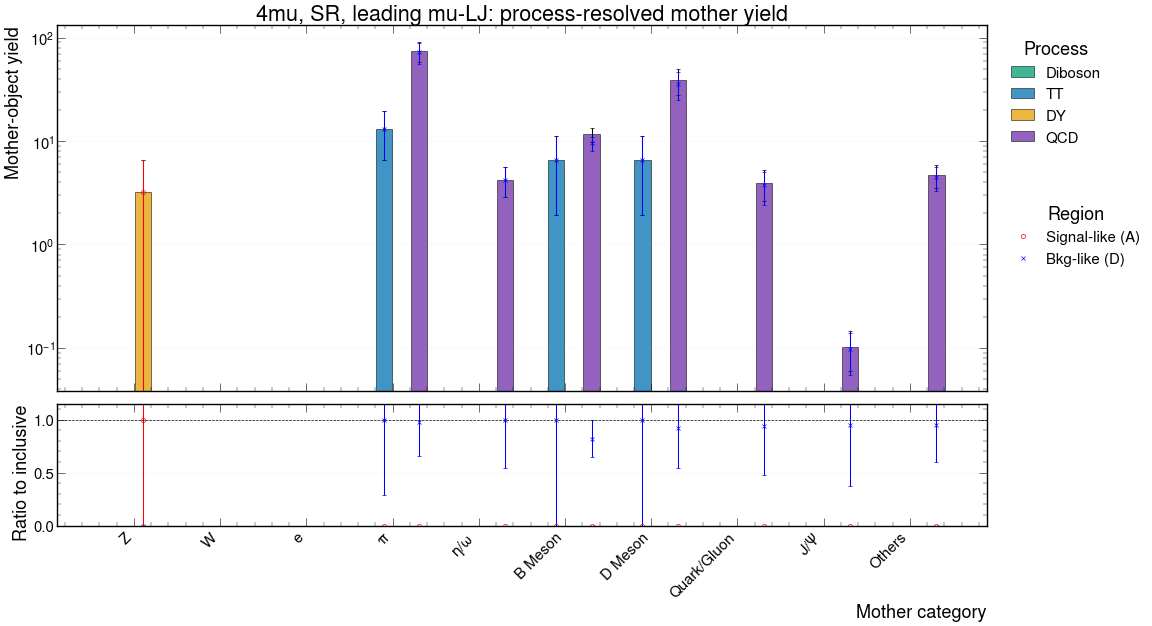

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


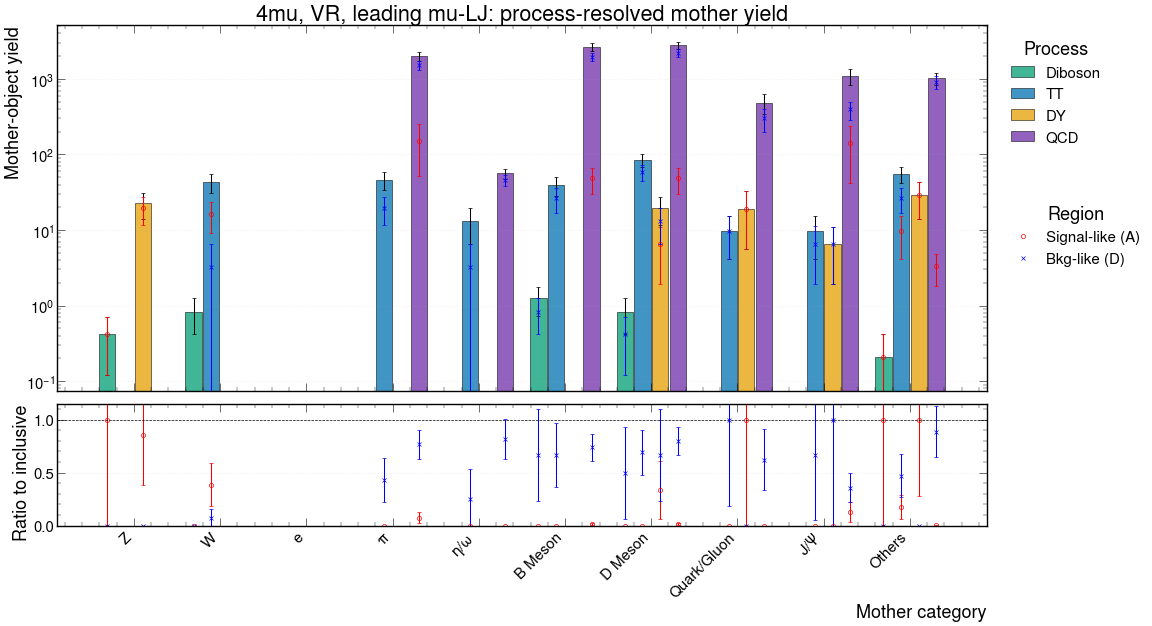

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


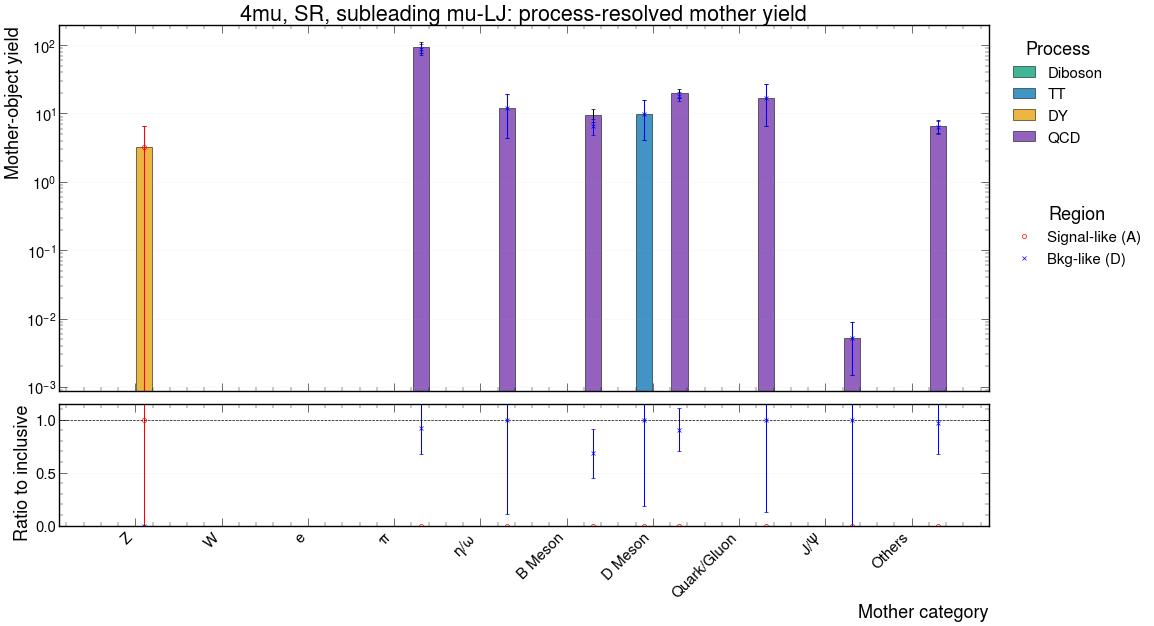

/tmp/ipykernel_7043/3396182166.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


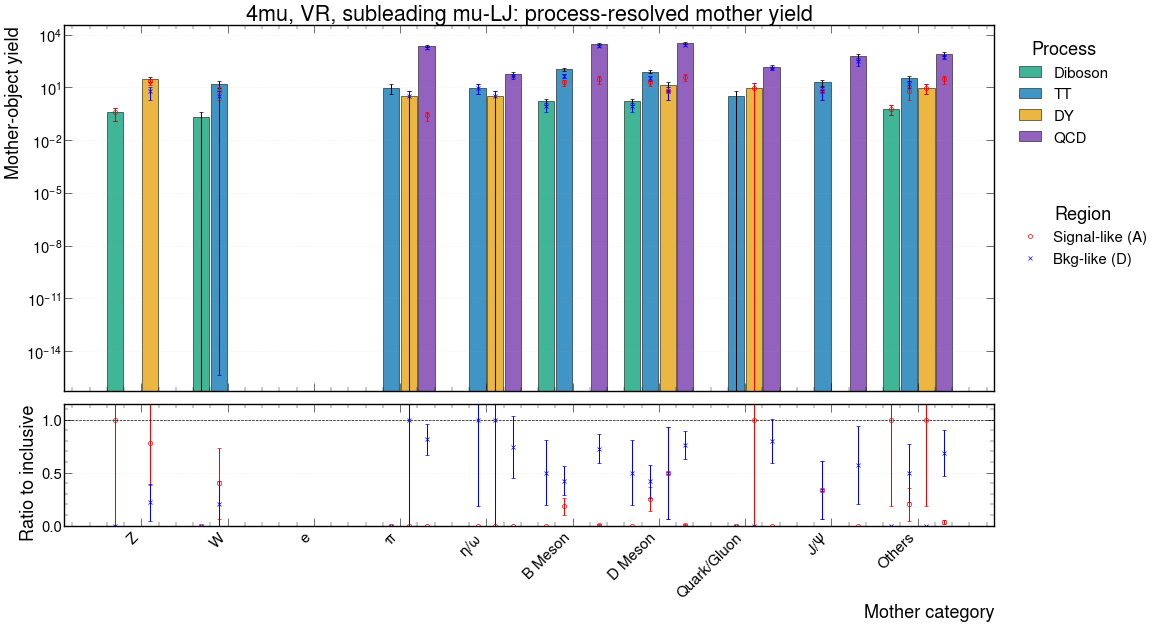

In [12]:
def process_mother_tables(topology, role, selection):
    region_yields = {}
    region_variances = {}
    for region in ABCD_REGIONS:
        yield_rows = {}
        variance_rows = {}
        for group, samples in BACKGROUND_GROUPS.items():
            grouped_yields = defaultdict(float)
            grouped_variances = defaultdict(float)
            for sample in samples:
                sample_yields, sample_variances = categorize_mother_histogram(
                    mother_histogram(sample, topology, role, selection, region)
                )
                for category in MOTHER_CATEGORY_ORDER:
                    grouped_yields[category] += sample_yields[category]
                    grouped_variances[category] += sample_variances[category]
            yield_rows[group] = grouped_yields
            variance_rows[group] = grouped_variances
        region_yields[region] = pd.DataFrame(yield_rows).T.reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        region_variances[region] = pd.DataFrame(variance_rows).T.reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
    inclusive_yield = sum(region_yields.values())
    inclusive_variance = sum(region_variances.values())
    return {
        "Inclusive": inclusive_yield,
        "Signal-like": region_yields["A"],
        "Bkg-like": region_yields["D"],
        "_errors": {
            "Inclusive": np.sqrt(inclusive_variance),
            "Signal-like": np.sqrt(region_variances["A"]),
            "Bkg-like": np.sqrt(region_variances["D"]),
        },
    }


def plot_process_mother_overlay(tables, title):
    inclusive = tables["Inclusive"]
    signal = tables["Signal-like"]
    background = tables["Bkg-like"]
    errors = tables["_errors"]
    categories = list(inclusive.columns)
    processes = list(inclusive.index)
    x = np.arange(len(categories))
    width = 0.82 / len(processes)
    offsets = (np.arange(len(processes)) - (len(processes) - 1) / 2) * width
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(24, 13), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    for index, process in enumerate(processes):
        positions = x + offsets[index]
        inc = inclusive.loc[process].to_numpy(float)
        inc_err = errors["Inclusive"].loc[process].to_numpy(float)
        sig = signal.loc[process].to_numpy(float)
        sig_err = errors["Signal-like"].loc[process].to_numpy(float)
        bkg = background.loc[process].to_numpy(float)
        bkg_err = errors["Bkg-like"].loc[process].to_numpy(float)
        ax.bar(positions, inc, width=0.92*width, color=GROUP_COLORS[process], edgecolor="black", alpha=0.75, label=process)
        mask = inc > 0
        ax.errorbar(positions[mask], inc[mask], yerr=inc_err[mask], fmt="none", ecolor="black", capsize=3)
        sig_mask = sig > 0
        bkg_mask = bkg > 0
        ax.errorbar(positions[sig_mask], sig[sig_mask], yerr=sig_err[sig_mask], marker="o", markerfacecolor="none",
                    markeredgecolor="red", ecolor="red", capsize=3, linestyle="none")
        ax.errorbar(positions[bkg_mask], bkg[bkg_mask], yerr=bkg_err[bkg_mask], marker="x",
                    color="blue", ecolor="blue", capsize=3, linestyle="none")
        sig_ratio, sig_ratio_error = ratio_uncertainty(sig, sig_err, inc, inc_err)
        bkg_ratio, bkg_ratio_error = ratio_uncertainty(bkg, bkg_err, inc, inc_err)
        for ratio, ratio_error, marker, color in (
            (sig_ratio, sig_ratio_error, "o", "red"), (bkg_ratio, bkg_ratio_error, "x", "blue")
        ):
            valid = np.isfinite(ratio)
            rax.errorbar(positions[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                         markerfacecolor="none" if marker == "o" else color, color=color,
                         ecolor=color, capsize=3, linestyle="none")
    ax.set_yscale("log")
    ax.set(title=title, ylabel="Mother-object yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    from matplotlib.lines import Line2D
    process_legend = ax.legend(title="Process", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.add_artist(process_legend)
    ax.legend(handles=[
        Line2D([], [], marker="o", markerfacecolor="none", color="red", linestyle="none", label="Signal-like (A)"),
        Line2D([], [], marker="x", color="blue", linestyle="none", label="Bkg-like (D)"),
    ], title="Region", bbox_to_anchor=(1.01, 0.55), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Mother category", ylim=(0, 1.15))
    rax.set_xticks(x, categories, rotation=45, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

process_mother_overlay_tables = {}
for topology, config in TOPOLOGY_CONFIG.items():
    process_mother_overlay_tables[topology] = {}
    for role in config["roles"]:
        process_mother_overlay_tables[topology][role] = {}
        for selection in ("SR", "VR"):
            tables = process_mother_tables(topology, role, selection)
            process_mother_overlay_tables[topology][role][selection] = tables
            plot_process_mother_overlay(tables, f"{topology}, {selection}, {role}: process-resolved mother yield")

## Compact landing summary

For each region, report the total event yield, dominant background process, and dominant mother category for each LJ role.

In [13]:
summary_rows = []
for topology, config in TOPOLOGY_CONFIG.items():
    source_table = group_landing_yields[topology]
    for region_label in source_table.index:
        row = {
            "topology": topology,
            "region": region_label,
            "event_yield": source_table.loc[region_label].sum(),
            "dominant_background": source_table.loc[region_label].idxmax(),
        }
        for role in config["roles"]:
            composition = mother_yields[topology][role].loc[region_label]
            row[f"{role}: mother_yield"] = composition.sum()
            row[f"{role}: dominant_mother"] = composition.idxmax() if composition.sum() != 0 else "empty"
        summary_rows.append(row)

landing_summary = pd.DataFrame(summary_rows).set_index(["topology", "region"])
display(landing_summary.round(4))

event_yield dominant_background  mu-LJ: mother_yield  \
topology region                                                         
2mu2e    SR-A       101.5550                 QCD             263.2403   
         SR-B       129.0103                 QCD             618.7212   
         SR-C        30.9591                 QCD             145.5012   
         SR-D       366.3532                 QCD            1362.1470   
         VR-A       129.4535                  TT             472.1692   
         VR-B       877.5323                  TT            3438.6520   
         VR-C       992.8507                 QCD            3108.7765   
         VR-D      4322.2463                 QCD           16327.5761   
4mu      SR-A         3.2506                  DY                  NaN   
         SR-B         0.7521                 QCD                  NaN   
         SR-C         1.8063                 QCD                  NaN   
         SR-D        32.1116                 QCD                  NaN   
         VR-A       140.5794                 QCD                  NaN   
         VR-B       271.6606                 QCD                  NaN   
         VR-C       430.0422                 QCD                  NaN   
         VR-D      1973.0240                 QCD                  NaN   

                mu-LJ: dominant_mother  egm-LJ: mother_yield  \
topology region                                                
2mu2e    SR-A                    $\pi$               51.0956   
         SR-B                  D Meson              362.6573   
         SR-C                  B Meson              103.0405   
         SR-D                  D Meson              899.3128   
         VR-A                  B Meson              200.5121   
         VR-B                  D Meson             1417.2651   
         VR-C                  B Meson             2555.3950   
         VR-D                  D Meson             9353.2880   
4mu      SR-A                      NaN                   NaN   
         SR-B                      NaN                   NaN   
         SR-C                      NaN                   NaN   
         SR-D                      NaN                   NaN   
         VR-A                      NaN                   NaN   
         VR-B                      NaN                   NaN   
         VR-C                      NaN                   NaN   
         VR-D                      NaN                   NaN   

                egm-LJ: dominant_mother  leading mu-LJ: mother_yield  \
topology region                                                        
2mu2e    SR-A                     $\pi$                          NaN   
         SR-B                     $\pi$                          NaN   
         SR-C                     $\pi$                          NaN   
         SR-D                     $\pi$                          NaN   
         VR-A                         W                          NaN   
         VR-B                         W                          NaN   
         VR-C                     $\pi$                          NaN   
         VR-D                   B Meson                          NaN   
4mu      SR-A                       NaN                       3.2480   
         SR-B                       NaN                       1.8863   
         SR-C                       NaN                       5.7721   
         SR-D                       NaN                     156.1403   
         VR-A                       NaN                     493.2812   
         VR-B                       NaN                     977.6706   
         VR-C                       NaN                    1488.1368   
         VR-D                       NaN                    7553.0889   

                leading mu-LJ: dominant_mother  \
topology region                                  
2mu2e    SR-A                              NaN   
         SR-B                              NaN   
         SR-C                              NaN   
  

## Optional exports

Uncomment only when persistent CSV products are needed. Notebook execution itself does not write analysis tables.

In [14]:
# EXPORT_DIR = study_dir / "ABCD_landing_mother_tables"
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# landing_summary.to_csv(EXPORT_DIR / "landing_summary.csv")
# for topology, table in sample_landing_yields.items():
#     table.to_csv(EXPORT_DIR / f"{topology}_sample_landing_yields.csv")
# for topology, role_tables in mother_yields_by_source.items():
#     for role, table in role_tables.items():
#         safe_role = role.replace(" ", "_").replace("-", "")
#         table.to_csv(EXPORT_DIR / f"{topology}_{safe_role}_mother_yields_by_source.csv")